# AI-READI Dataset - Exploratory Data Analysis

**True exploratory data analysis focused on diabetes trends, multi-modal patterns, and machine learning insights.**

---

## Table of Contents

1. [Introduction & Context](#1-introduction--context)
2. [Data Loading & Preparation](#2-data-loading--preparation)
3. [Cohort Characterization](#3-cohort-characterization)
4. [Glucose Dynamics Analysis](#4-glucose-dynamics-analysis)
5. [Cardiac-Metabolic Connections](#5-cardiac-metabolic-connections)
6. [Lifestyle & Behavior Patterns](#6-lifestyle--behavior-patterns)
7. [Patient Phenotyping](#7-patient-phenotyping)
8. [Clinical Patterns](#8-clinical-patterns)
9. [Key Findings & Summary](#9-key-findings--summary)
10. [Next Steps & ML Roadmap](#10-next-steps--ml-roadmap)

---

## 1. Introduction & Context

### What is Type 2 Diabetes?

**Type 2 Diabetes (T2D)** is a chronic metabolic disorder characterized by:
- **Insulin resistance**: Body cells don't respond properly to insulin
- **Beta-cell dysfunction**: Pancreas eventually can't produce enough insulin
- **Hyperglycemia**: Chronically elevated blood glucose levels

**Normal Glucose Ranges:**
- Fasting: 70-100 mg/dL (healthy)
- Postprandial (after meals): < 140 mg/dL (healthy)
- Diabetes diagnosis: Fasting ≥ 126 mg/dL or HbA1c ≥ 6.5%

**Disease Progression:**
```
Healthy → Pre-diabetes → T2D (oral meds) → T2D (insulin required)
```

### What is the AI-READI Dataset?

**AI-READI** = Artificial Intelligence Ready and Equitable Atlas for Diabetes Health

- **NIH-funded flagship dataset** (OT2OD032644) for AI/ML diabetes research
- **2,280 participants** collected July 2023 - May 2025
- **Multi-modal data**: Clinical, CGM, ECG, wearable activity, environmental sensors, retinal imaging
- **Study groups**: Healthy, pre-diabetes, oral medication, insulin controlled

### Key Clinical Metrics

**Glucose Metrics (from CGM - Continuous Glucose Monitoring):**
- **Mean Glucose**: Average blood sugar over monitoring period
- **Time in Range (TIR)**: % of time glucose is 70-180 mg/dL (target: >70%)
- **Time Above Range (TAR)**: % of time glucose > 180 mg/dL (target: <25%)
- **Time Below Range (TBR)**: % of time glucose < 70 mg/dL (target: <4%)
- **Coefficient of Variation (CV)**: (std/mean) × 100%, measures variability (target: <36%)
- **Glucose Management Indicator (GMI)**: Estimated HbA1c from CGM data

**Cardiac Metrics (from ECG):**
- **Heart Rate (HR)**: Normal resting 60-100 bpm
- **QTc (Corrected QT)**: Cardiac repolarization time, prolonged if >450ms (arrhythmia risk)
- **PR Interval**: Atrial to ventricular activation time
- **QRS Duration**: Ventricular depolarization time

**Activity Metrics (from Garmin wearables):**
- Average heart rate, O2 saturation, stress level, sleep hours, daily activity, active calories

For detailed medical background, see [AIREADI_INTRO.md](../guides/AIREADI_INTRO.md)

## 2. Data Loading & Preparation

In [27]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


In [2]:
# Load merged dataset
data_path = Path('../data/samples/eda_merged_dataset.csv')

if not data_path.exists():
    print("⚠️ Dataset not found!")
    print(f"\nSearched at: {data_path.absolute()}")
    print("\n" + "="*60)
    print("INSTRUCTIONS:")
    print("="*60)
    print("\nRun these scripts to generate the dataset:")
    print("  1. python3 scripts/download_cgm_samples.py")
    print("  2. python3 scripts/calculate_glucose_metrics.py")
    print("  3. python3 scripts/prepare_eda_dataset.py")
else:
    df = pd.read_csv(data_path)
    print(f"✓ Dataset loaded successfully!")
    print(f"✓ Participants: {len(df)}")
    print(f"✓ Features: {len(df.columns)}")
    print(f"✓ Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"\nDataset preview:")
    display(df.head())

✓ Dataset loaded successfully!
✓ Participants: 52
✓ Features: 37
✓ Memory usage: 0.02 MB

Dataset preview:


,person_id,study_group,age,n_readings,mean_glucose,median_glucose,std_glucose,cv_glucose,min_glucose,max_glucose,glucose_range,tir,tar,tar_level1,tar_level2,tbr,tbr_level1,tbr_level2,gmi,clinical_site,study_visit_date,Rate,PR,QRSD,QT,QTc,P,QRS,T,average_heartrate_bpm,average_oxygen_saturation_pct,average_stress_level,average_sleep_hours,average_respiratory_rate_bpm,average_daily_activity,average_active_calories_kcal,sensor_sampling_duration_days
0,1023,insulin_dependent,67,2816,132.13,129.0,25.59,19.36,63.0,237.0,174.0,94.64,5.26,5.26,0.00,0.11,0.11,0.00,6.47,UW,2023-08-30,77.0,180.0,90.0,360.0,408.0,8.0,39.0,25.0,79.36,91.71,15.37,0.28,7.02,7797.21,294.11,18.0
1,1024,pre_diabetes_lifestyle_controlled,63,2848,127.39,119.0,29.56,23.20,44.0,295.0,251.0,94.59,5.20,4.67,0.53,0.21,0.04,0.18,6.36,UW,2023-08-31,77.0,160.0,87.0,371.0,420.0,63.0,76.0,47.0,69.15,90.29,13.27,0.42,3.69,4565.00,272.65,27.0
2,1026,pre_diabetes_lifestyle_controlled,66,2574,122.65,116.0,20.92,17.06,72.0,243.0,171.0,97.59,2.41,2.41,0.00,0.00,0.00,0.00,6.24,UW,2023-09-01,57.0,185.0,85.0,417.0,406.0,-19.0,-25.0,4.0,66.10,92.32,13.46,0.27,4.49,5217.00,197.01,21.0
3,1027,oral_medication_and_or_non_insulin_injectable_...,53,1606,345.03,351.0,38.26,11.09,234.0,400.0,166.0,0.00,100.00,0.93,99.07,0.00,0.00,0.00,11.56,UW,2023-09-05,97.0,175.0,76.0,326.0,414.0,67.0,50.0,-40.0,89.02,93.22,11.18,0.36,1.03,10505.23,465.48,22.0
4,1029,pre_diabetes_lifestyle_controlled,73,2856,110.71,109.0,11.64,10.51,84.0,165.0,81.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,5.96,UW,2023-09-07,55.0,194.0,103.0,415.0,397.0,48.0,-12.0,26.0,70.85,92.99,18.57,0.43,9.61,7562.31,159.48,13.0


In [3]:
# Display first few rows
df.head()

,person_id,study_group,age,n_readings,mean_glucose,median_glucose,std_glucose,cv_glucose,min_glucose,max_glucose,glucose_range,tir,tar,tar_level1,tar_level2,tbr,tbr_level1,tbr_level2,gmi,clinical_site,study_visit_date,Rate,PR,QRSD,QT,QTc,P,QRS,T,average_heartrate_bpm,average_oxygen_saturation_pct,average_stress_level,average_sleep_hours,average_respiratory_rate_bpm,average_daily_activity,average_active_calories_kcal,sensor_sampling_duration_days
0,1023,insulin_dependent,67,2816,132.13,129.0,25.59,19.36,63.0,237.0,174.0,94.64,5.26,5.26,0.00,0.11,0.11,0.00,6.47,UW,2023-08-30,77.0,180.0,90.0,360.0,408.0,8.0,39.0,25.0,79.36,91.71,15.37,0.28,7.02,7797.21,294.11,18.0
1,1024,pre_diabetes_lifestyle_controlled,63,2848,127.39,119.0,29.56,23.20,44.0,295.0,251.0,94.59,5.20,4.67,0.53,0.21,0.04,0.18,6.36,UW,2023-08-31,77.0,160.0,87.0,371.0,420.0,63.0,76.0,47.0,69.15,90.29,13.27,0.42,3.69,4565.00,272.65,27.0
2,1026,pre_diabetes_lifestyle_controlled,66,2574,122.65,116.0,20.92,17.06,72.0,243.0,171.0,97.59,2.41,2.41,0.00,0.00,0.00,0.00,6.24,UW,2023-09-01,57.0,185.0,85.0,417.0,406.0,-19.0,-25.0,4.0,66.10,92.32,13.46,0.27,4.49,5217.00,197.01,21.0
3,1027,oral_medication_and_or_non_insulin_injectable_...,53,1606,345.03,351.0,38.26,11.09,234.0,400.0,166.0,0.00,100.00,0.93,99.07,0.00,0.00,0.00,11.56,UW,2023-09-05,97.0,175.0,76.0,326.0,414.0,67.0,50.0,-40.0,89.02,93.22,11.18,0.36,1.03,10505.23,465.48,22.0
4,1029,pre_diabetes_lifestyle_controlled,73,2856,110.71,109.0,11.64,10.51,84.0,165.0,81.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,5.96,UW,2023-09-07,55.0,194.0,103.0,415.0,397.0,48.0,-12.0,26.0,70.85,92.99,18.57,0.43,9.61,7562.31,159.48,13.0


In [4]:
# Summary statistics
df.describe()

,person_id,age,n_readings,mean_glucose,median_glucose,std_glucose,cv_glucose,min_glucose,max_glucose,glucose_range,tir,tar,tar_level1,tar_level2,tbr,tbr_level1,tbr_level2,gmi,Rate,PR,QRSD,QT,QTc,P,QRS,T,average_heartrate_bpm,average_oxygen_saturation_pct,average_stress_level,average_sleep_hours,average_respiratory_rate_bpm,average_daily_activity,average_active_calories_kcal,sensor_sampling_duration_days
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,25.000000,24.000000,25.000000,25.000000,25.000000,24.000000,25.000000,24.00000,25.00000,24.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.00000
mean,2612.307692,58.923077,2769.384615,141.432115,137.980769,26.592885,18.758654,70.519231,247.942308,177.423077,85.063846,14.507308,9.966731,4.540577,0.429615,0.336923,0.093462,6.692885,68.480000,172.250000,95.120000,398.760000,421.200000,50.708333,36.280000,39.12500,73.15320,91.528750,19.114400,0.361600,6.060000,6248.419600,261.672000,20.68000
std,2372.479265,10.662094,232.856529,43.335595,44.051436,10.185447,4.733101,32.067020,63.093585,50.531429,24.059027,24.244465,14.176369,16.667756,1.250300,1.095367,0.209180,1.036176,13.444702,26.559613,16.563816,33.537641,25.344296,31.722272,45.459249,29.33215,9.87049,1.289814,12.492857,0.047406,3.396534,3217.278513,132.383136,7.18633
min,1023.000000,40.000000,1606.000000,95.750000,94.000000,11.640000,10.510000,40.000000,165.000000,81.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.600000,43.000000,113.000000,76.000000,326.000000,387.000000,-25.000000,-61.000000,-40.00000,52.53000,89.180000,6.950000,0.270000,0.880000,1634.070000,52.070000,8.00000
25%,1037.750000,49.750000,2813.000000,116.050000,112.750000,19.592500,16.222500,52.250000,201.750000,143.000000,83.855000,0.717500,0.717500,0.000000,0.000000,0.000000,0.000000,6.085000,58.000000,159.750000,84.000000,375.000000,406.000000,33.000000,-2.000000,25.75000,66.76000,90.420000,11.180000,0.330000,3.690000,4097.290000,153.900000,16.00000
50%,1085.500000,59.000000,2851.500000,127.535000,121.000000,25.175000,18.445000,65.500000,233.500000,171.000000,95.180000,4.510000,3.875000,0.000000,0.125000,0.070000,0.000000,6.360000,69.000000,171.500000,88.000000,401.000000,420.000000,63.500000,44.000000,40.00000,75.65000,91.725000,15.370000,0.380000,6.010000,5573.780000,266.850000,20.00000
75%,4353.750000,67.000000,2856.000000,152.382500,151.000000,29.582500,20.305000,79.000000,275.000000,192.250000,98.690000,15.935000,13.887500,0.532500,0.327500,0.320000,0.057500,6.955000,77.000000,194.000000,101.000000,424.000000,427.000000,73.000000,72.000000,52.00000,79.36000,92.350000,24.140000,0.390000,8.410000,7797.210000,373.540000,23.00000
max,7798.000000,81.000000,2856.000000,345.030000,351.000000,54.040000,33.040000,234.000000,400.000000,335.000000,100.000000,100.000000,55.020000,99.070000,8.890000,7.870000,1.020000,11.560000,97.000000,207.000000,145.000000,468.000000,487.000000,89.000000,130.000000,88.00000,91.53000,93.720000,65.090000,0.430000,13.250000,15222.300000,472.560000,38.00000


## 3. Cohort Characterization

Understanding the demographics and composition of our study cohort.

In [5]:
# Study group distribution
print("Study Group Distribution:")
print(df['study_group'].value_counts())
print(f"\nTotal participants: {len(df)}")

Study Group Distribution:
study_group
pre_diabetes_lifestyle_controlled                                      17
healthy                                                                15
insulin_dependent                                                      10
oral_medication_and_or_non_insulin_injectable_medication_controlled    10
Name: count, dtype: int64

Total participants: 52


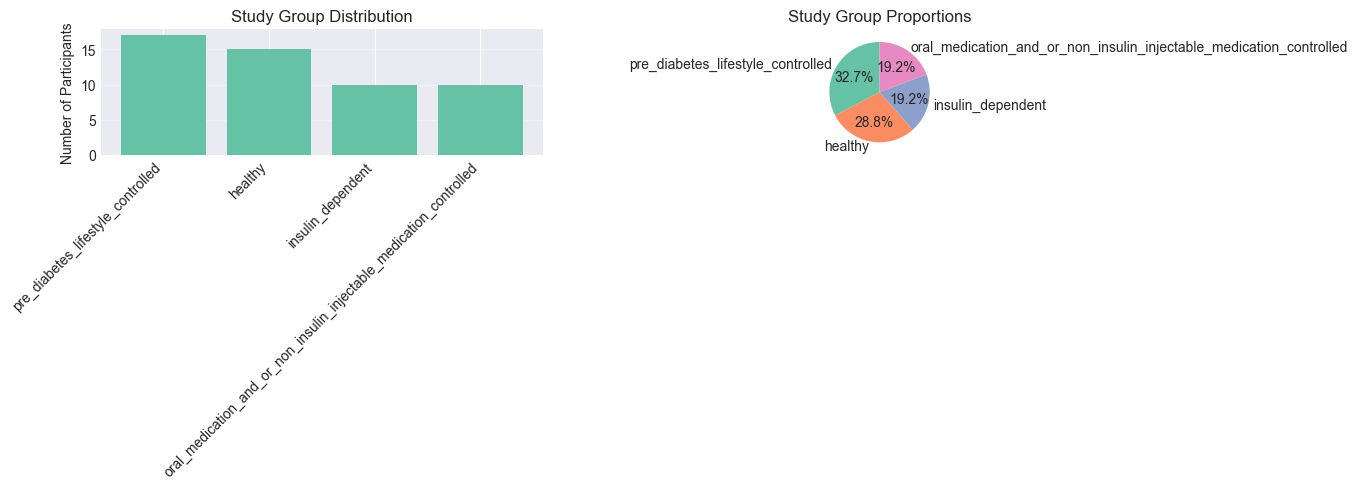

In [6]:
# Visualize study group proportions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
study_counts = df['study_group'].value_counts()
ax1.bar(range(len(study_counts)), study_counts.values)
ax1.set_xticks(range(len(study_counts)))
ax1.set_xticklabels(study_counts.index, rotation=45, ha='right')
ax1.set_ylabel('Number of Participants')
ax1.set_title('Study Group Distribution')
ax1.grid(axis='y', alpha=0.3)

# Pie chart
ax2.pie(study_counts.values, labels=study_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Study Group Proportions')

plt.tight_layout()
plt.show()

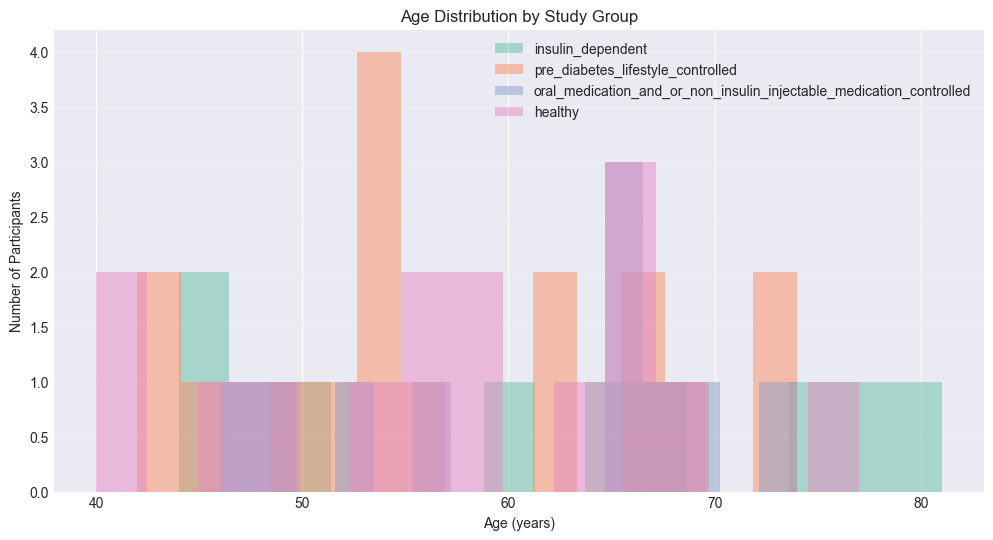


Age Statistics by Study Group:
                                                    count       mean  \
study_group                                                            
healthy                                              15.0  57.666667   
insulin_dependent                                    10.0  61.100000   
oral_medication_and_or_non_insulin_injectable_m...   10.0  61.200000   
pre_diabetes_lifestyle_controlled                    17.0  57.411765   

                                                          std   min    25%  \
study_group                                                                  
healthy                                             10.621183  40.0  51.00   
insulin_dependent                                   13.811831  44.0  48.25   
oral_medication_and_or_non_insulin_injectable_m...   9.354737  46.0  54.00   
pre_diabetes_lifestyle_controlled                    9.849231  42.0  51.00   

                                                     50%    75%   

In [7]:
# Age distribution by study group
if 'age' in df.columns:
    plt.figure(figsize=(12, 6))
    
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]['age'].dropna()
        plt.hist(group_data, alpha=0.5, label=group, bins=15)
    
    plt.xlabel('Age (years)')
    plt.ylabel('Number of Participants')
    plt.title('Age Distribution by Study Group')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    # Summary statistics by group
    print("\nAge Statistics by Study Group:")
    print(df.groupby('study_group')['age'].describe())
else:
    print("Age data not available in dataset")

Data Completeness:

Columns with missing data:
  T: 53.8% missing
  PR: 53.8% missing
  average_oxygen_saturation_pct: 53.8% missing
  P: 53.8% missing
  QRS: 51.9% missing
  Rate: 51.9% missing
  QRSD: 51.9% missing
  QT: 51.9% missing
  QTc: 51.9% missing
  sensor_sampling_duration_days: 51.9% missing
  average_heartrate_bpm: 51.9% missing
  average_stress_level: 51.9% missing
  average_sleep_hours: 51.9% missing
  average_respiratory_rate_bpm: 51.9% missing
  average_daily_activity: 51.9% missing
  average_active_calories_kcal: 51.9% missing


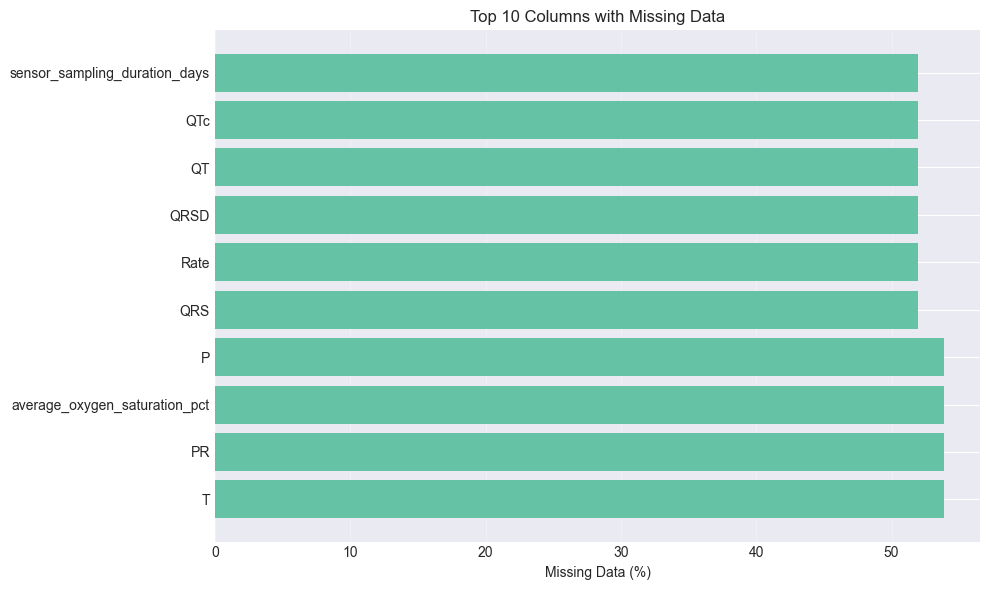

In [8]:
# Data completeness analysis
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

print("Data Completeness:")
if missing_pct.max() > 0:
    print("\nColumns with missing data:")
    for col, pct in missing_pct[missing_pct > 0].items():
        print(f"  {col}: {pct:.1f}% missing")
    
    # Visualize
    plt.figure(figsize=(10, 6))
    missing_cols = missing_pct[missing_pct > 0].head(10)
    plt.barh(range(len(missing_cols)), missing_cols.values)
    plt.yticks(range(len(missing_cols)), missing_cols.index)
    plt.xlabel('Missing Data (%)')
    plt.title('Top 10 Columns with Missing Data')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing data!")

## 4. Glucose Dynamics Analysis

**Understanding glycemic control across diabetes severity levels.**

Key questions:
- How does mean glucose differ between study groups?
- Is glucose variability higher in advanced diabetes?
- What percentage of participants meet clinical TIR targets (>70%)?

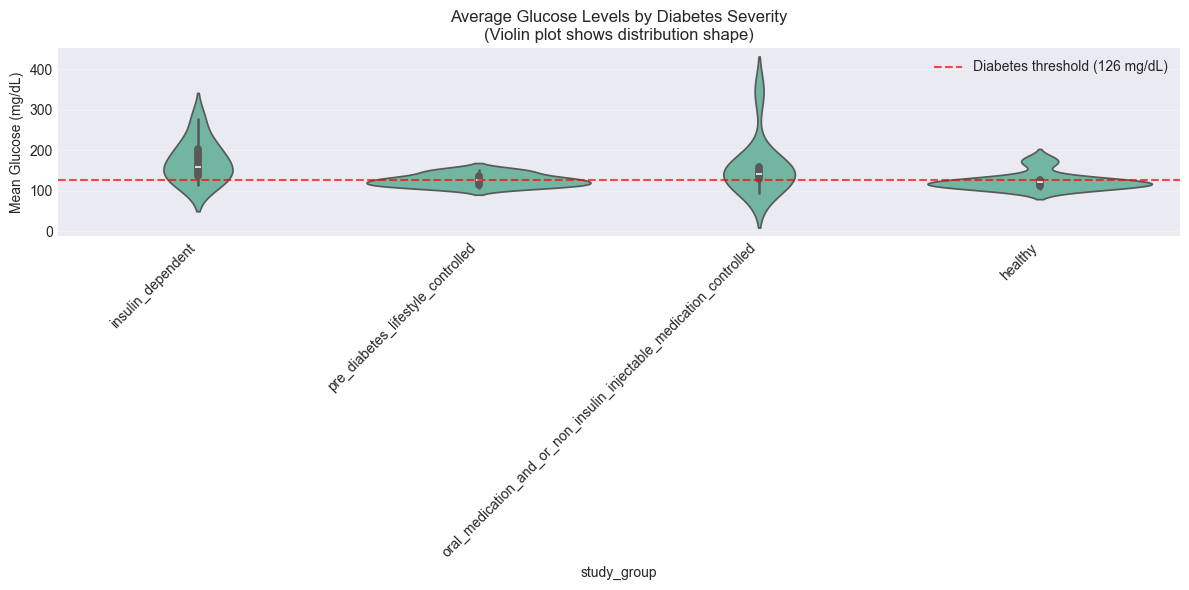


Mean Glucose Statistics by Study Group:
                                                    count        mean  \
study_group                                                             
healthy                                              15.0  124.937333   
insulin_dependent                                    10.0  173.011000   
oral_medication_and_or_non_insulin_injectable_m...   10.0  159.363000   
pre_diabetes_lifestyle_controlled                    17.0  126.862941   

                                                          std     min  \
study_group                                                             
healthy                                             21.038130  104.00   
insulin_dependent                                   50.701240  113.59   
oral_medication_and_or_non_insulin_injectable_m...  68.453972   95.75   
pre_diabetes_lifestyle_controlled                   14.564810  107.07   

                                                         25%      50%  \
study_gr

In [9]:
# Mean glucose by study group
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='study_group', y='mean_glucose', inner='box')
plt.axhline(126, color='red', linestyle='--', alpha=0.7, label='Diabetes threshold (126 mg/dL)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Glucose (mg/dL)')
plt.title('Average Glucose Levels by Diabetes Severity\n(Violin plot shows distribution shape)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMean Glucose Statistics by Study Group:")
print(df.groupby('study_group')['mean_glucose'].describe())

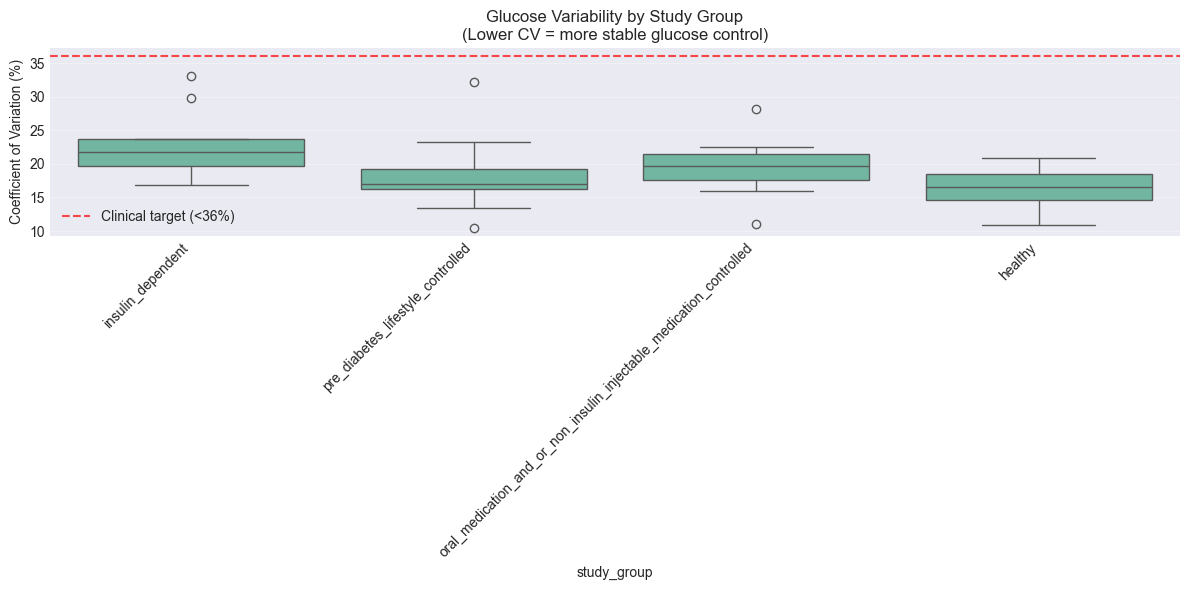


Glucose Variability (CV) Statistics:
                                                    count       mean  \
study_group                                                            
healthy                                              15.0  16.368000   
insulin_dependent                                    10.0  22.964000   
oral_medication_and_or_non_insulin_injectable_m...   10.0  19.524000   
pre_diabetes_lifestyle_controlled                    17.0  17.944118   

                                                         std    min      25%  \
study_group                                                                    
healthy                                             2.883421  10.95  14.5600   
insulin_dependent                                   4.970900  16.85  19.6975   
oral_medication_and_or_non_insulin_injectable_m...  4.485424  11.09  17.5525   
pre_diabetes_lifestyle_controlled                   4.629677  10.51  16.2800   

                                                

In [10]:
# Glucose variability (CV) by study group
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='study_group', y='cv_glucose')
plt.axhline(36, color='red', linestyle='--', alpha=0.7, label='Clinical target (<36%)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coefficient of Variation (%)')
plt.title('Glucose Variability by Study Group\n(Lower CV = more stable glucose control)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nGlucose Variability (CV) Statistics:")
print(df.groupby('study_group')['cv_glucose'].describe())

/var/folders/bd/34hytx5s50338ck7kxr6t55m0000gn/T/ipykernel_84341/3247484371.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


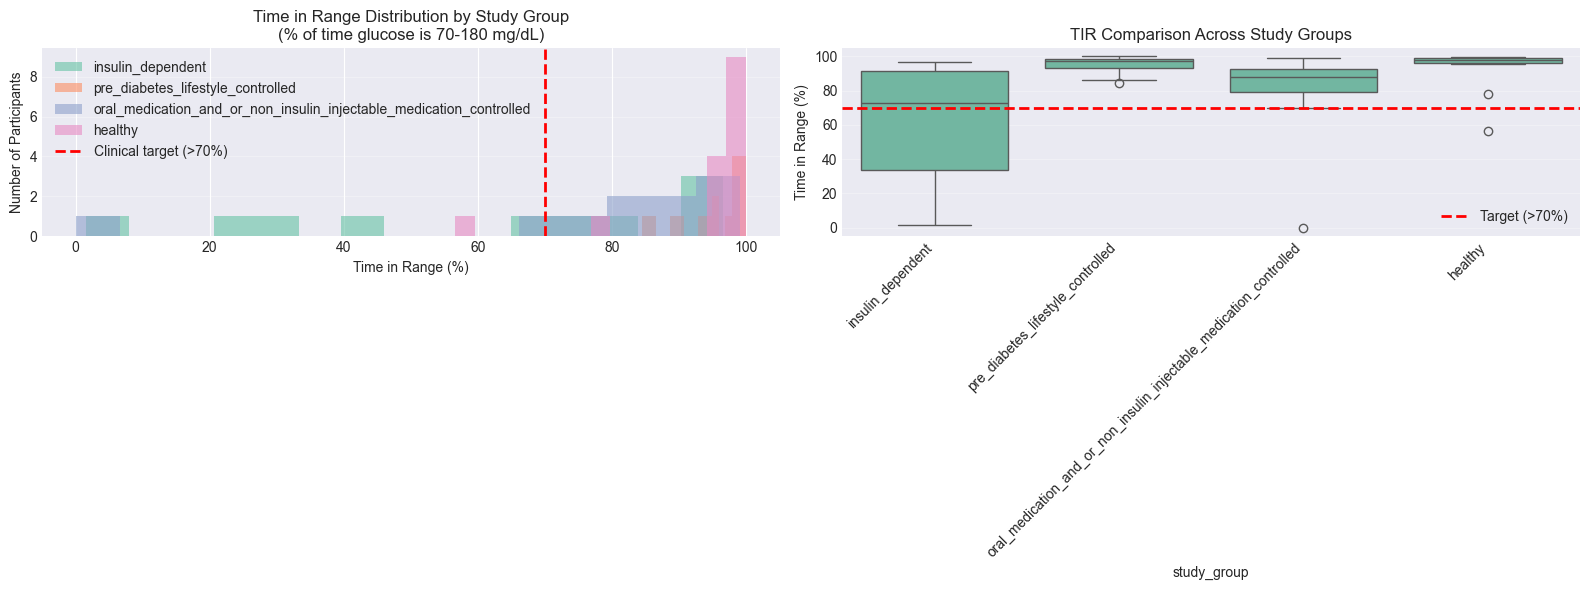


Time in Range (TIR) Analysis:
Overall mean TIR: 85.1% ± 24.1%
Participants meeting target (>70%): 45 / 52 (86.5%)

By study group:
  insulin_dependent: 6/10 (60.0%) meeting target
  pre_diabetes_lifestyle_controlled: 17/17 (100.0%) meeting target
  oral_medication_and_or_non_insulin_injectable_medication_controlled: 8/10 (80.0%) meeting target
  healthy: 14/15 (93.3%) meeting target


In [11]:
# Time in Range (TIR) analysis - THE GOLD STANDARD METRIC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution by study group
for group in df['study_group'].unique():
    group_data = df[df['study_group'] == group]['tir'].dropna()
    axes[0].hist(group_data, alpha=0.6, label=group, bins=15)

axes[0].axvline(70, color='red', linestyle='--', linewidth=2, label='Clinical target (>70%)')
axes[0].set_xlabel('Time in Range (%)')
axes[0].set_ylabel('Number of Participants')
axes[0].set_title('Time in Range Distribution by Study Group\n(% of time glucose is 70-180 mg/dL)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot comparison
sns.boxplot(data=df, x='study_group', y='tir', ax=axes[1])
axes[1].axhline(70, color='red', linestyle='--', linewidth=2, label='Target (>70%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('Time in Range (%)')
axes[1].set_title('TIR Comparison Across Study Groups')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate percentage meeting target
print("\nTime in Range (TIR) Analysis:")
print(f"Overall mean TIR: {df['tir'].mean():.1f}% ± {df['tir'].std():.1f}%")
print(f"Participants meeting target (>70%): {(df['tir'] > 70).sum()} / {len(df)} ({(df['tir'] > 70).mean()*100:.1f}%)")
print("\nBy study group:")
for group in df['study_group'].unique():
    group_data = df[df['study_group'] == group]
    meeting_target = (group_data['tir'] > 70).sum()
    total = len(group_data)
    print(f"  {group}: {meeting_target}/{total} ({meeting_target/total*100:.1f}%) meeting target")

/var/folders/bd/34hytx5s50338ck7kxr6t55m0000gn/T/ipykernel_84341/1432851293.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/var/folders/bd/34hytx5s50338ck7kxr6t55m0000gn/T/ipykernel_84341/1432851293.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


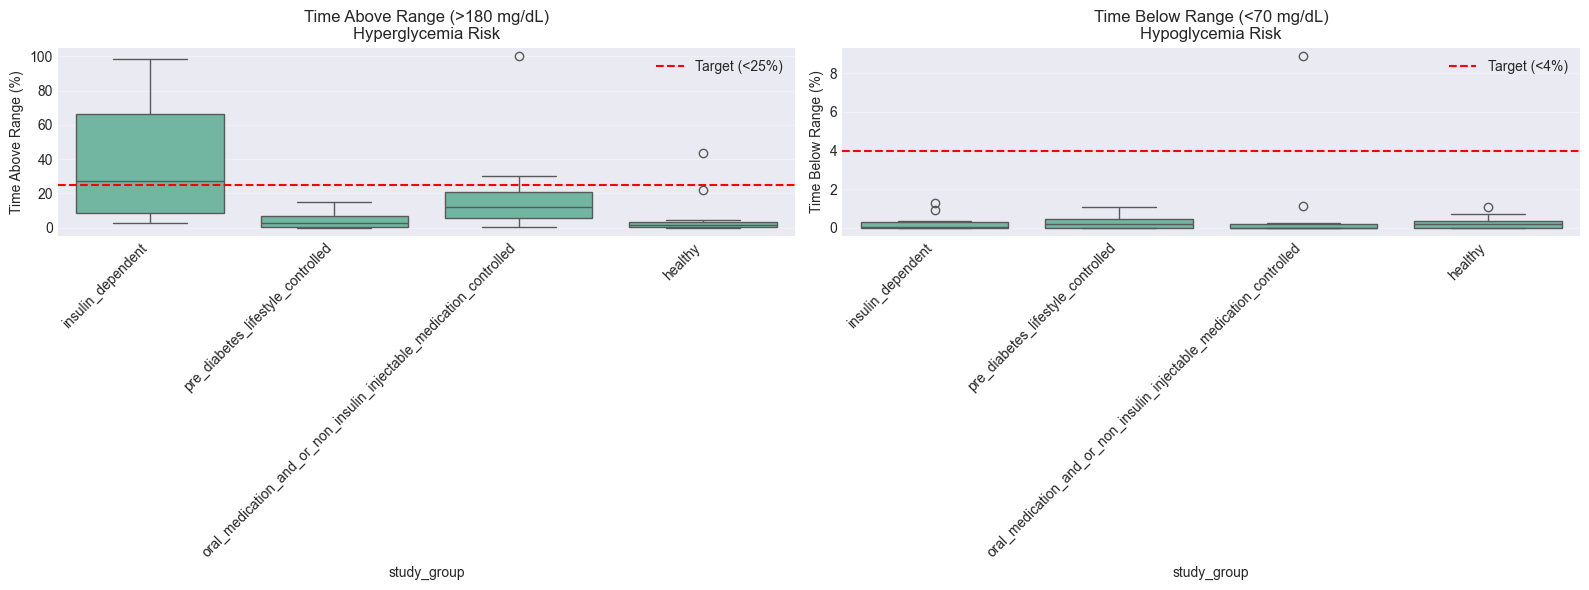


Hyperglycemia (TAR) Statistics:
                                                    count       mean  \
study_group                                                            
healthy                                              15.0   5.652667   
insulin_dependent                                    10.0  38.680000   
oral_medication_and_or_non_insulin_injectable_m...   10.0  20.746000   
pre_diabetes_lifestyle_controlled                    17.0   4.431176   

                                                          std   min     25%  \
study_group                                                                   
healthy                                             11.782860  0.00  0.3350   
insulin_dependent                                   34.494733  2.49  8.6800   
oral_medication_and_or_non_insulin_injectable_m...  29.436056  0.14  5.7425   
pre_diabetes_lifestyle_controlled                    4.949935  0.00  0.4200   

                                                       50% 

In [12]:
# Time Above Range (TAR) and Time Below Range (TBR)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# TAR
sns.boxplot(data=df, x='study_group', y='tar', ax=ax1)
ax1.axhline(25, color='red', linestyle='--', label='Target (<25%)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylabel('Time Above Range (%)')
ax1.set_title('Time Above Range (>180 mg/dL)\nHyperglycemia Risk')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# TBR
sns.boxplot(data=df, x='study_group', y='tbr', ax=ax2)
ax2.axhline(4, color='red', linestyle='--', label='Target (<4%)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylabel('Time Below Range (%)')
ax2.set_title('Time Below Range (<70 mg/dL)\nHypoglycemia Risk')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHyperglycemia (TAR) Statistics:")
print(df.groupby('study_group')['tar'].describe())
print("\nHypoglycemia (TBR) Statistics:")
print(df.groupby('study_group')['tbr'].describe())

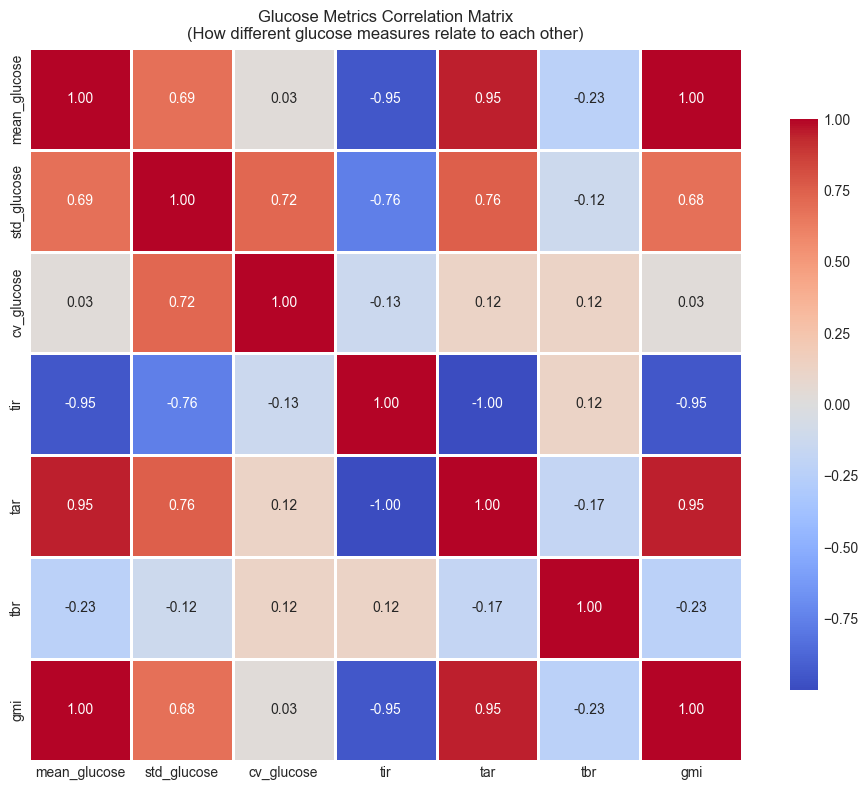


Key Correlations:
- High mean_glucose → Low TIR (negative correlation)
- High TAR → Low TIR (they're complementary measures)
- GMI tracks with mean_glucose (GMI is calculated from mean)


In [13]:
# Glucose metrics correlation matrix
glucose_cols = ['mean_glucose', 'std_glucose', 'cv_glucose', 'tir', 'tar', 'tbr', 'gmi']
available_glucose_cols = [col for col in glucose_cols if col in df.columns]

plt.figure(figsize=(10, 8))
corr_matrix = df[available_glucose_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Glucose Metrics Correlation Matrix\n(How different glucose measures relate to each other)')
plt.tight_layout()
plt.show()

print("\nKey Correlations:")
print("- High mean_glucose → Low TIR (negative correlation)")
print("- High TAR → Low TIR (they're complementary measures)")
print("- GMI tracks with mean_glucose (GMI is calculated from mean)")

## 5. Cardiac-Metabolic Connections

**Exploring the relationship between glucose control and cardiac health.**

Diabetes affects the cardiovascular system through:
- Autonomic neuropathy (damaged nerves controlling heart)
- Electrical conduction abnormalities
- Increased arrhythmia risk (QTc prolongation)

In [14]:
# Check if ECG data is available
ecg_cols = ['Rate', 'QTc', 'PR', 'QRSD', 'QT']
available_ecg = [col for col in ecg_cols if col in df.columns]

if len(available_ecg) > 0:
    print(f"✓ ECG data available: {available_ecg}")
else:
    print("⚠️ No ECG data in merged dataset")
    print("Skipping cardiac-metabolic analysis")

✓ ECG data available: ['Rate', 'QTc', 'PR', 'QRSD', 'QT']


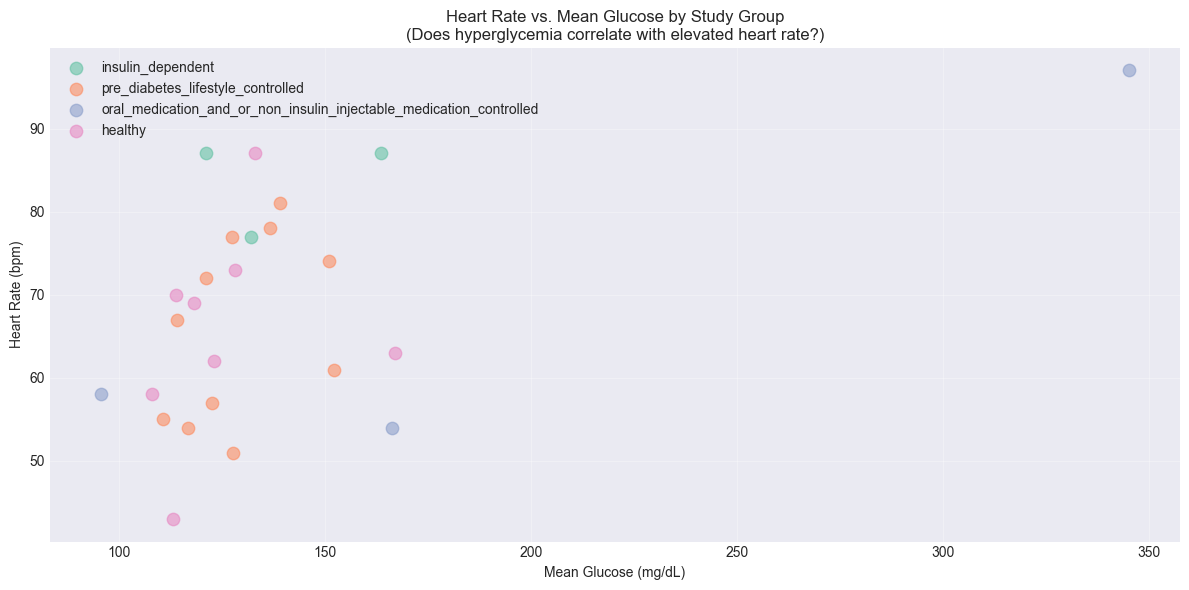


Correlation: 0.504
Moderate to strong correlation detected!


In [15]:
# Heart rate vs. mean glucose
if 'Rate' in df.columns:
    plt.figure(figsize=(12, 6))
    
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]
        plt.scatter(group_data['mean_glucose'], group_data['Rate'], 
                   alpha=0.6, label=group, s=80)
    
    plt.xlabel('Mean Glucose (mg/dL)')
    plt.ylabel('Heart Rate (bpm)')
    plt.title('Heart Rate vs. Mean Glucose by Study Group\n(Does hyperglycemia correlate with elevated heart rate?)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate correlation
    corr = df[['mean_glucose', 'Rate']].corr().iloc[0, 1]
    print(f"\nCorrelation: {corr:.3f}")
    if abs(corr) > 0.3:
        print("Moderate to strong correlation detected!")
    else:
        print("Weak correlation - heart rate and glucose may be independent")

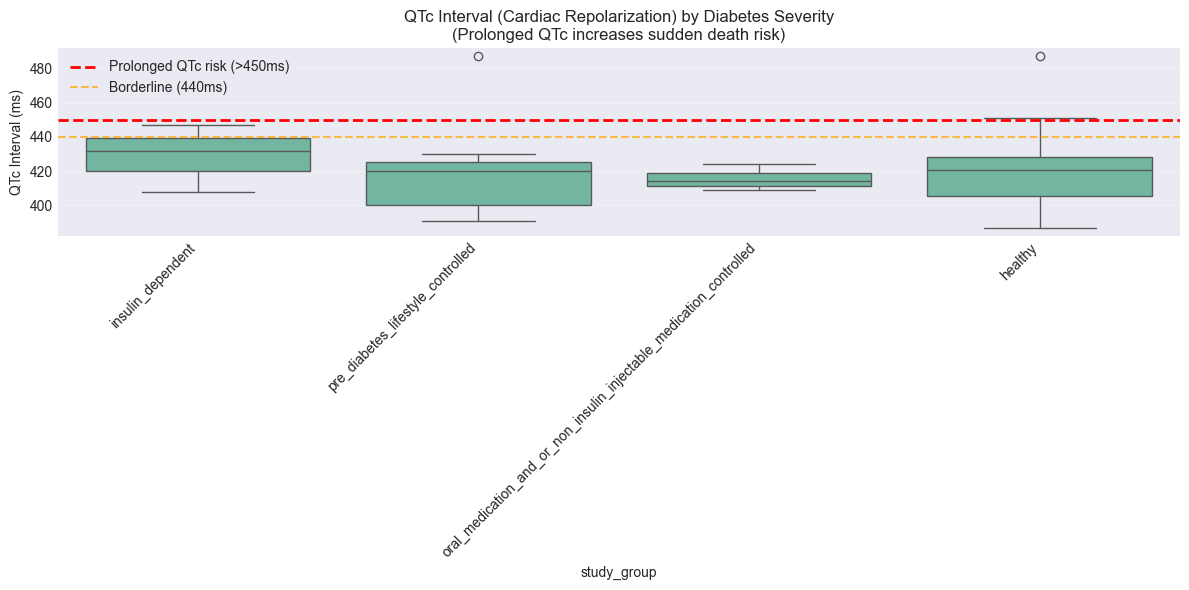


QTc Interval Statistics:
                                                    count        mean  \
study_group                                                             
healthy                                               8.0  424.000000   
insulin_dependent                                     3.0  429.000000   
oral_medication_and_or_non_insulin_injectable_m...    3.0  415.666667   
pre_diabetes_lifestyle_controlled                    11.0  418.545455   

                                                          std    min     25%  \
study_group                                                                    
healthy                                             31.870273  387.0  405.75   
insulin_dependent                                   19.672316  408.0  420.00   
oral_medication_and_or_non_insulin_injectable_m...   7.637626  409.0  411.50   
pre_diabetes_lifestyle_controlled                   26.458887  391.0  400.00   

                                                      

In [16]:
# QTc interval by study group (CRITICAL CARDIAC SAFETY METRIC)
if 'QTc' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='study_group', y='QTc')
    plt.axhline(450, color='red', linestyle='--', linewidth=2, 
                label='Prolonged QTc risk (>450ms)')
    plt.axhline(440, color='orange', linestyle='--', alpha=0.7, 
                label='Borderline (440ms)')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('QTc Interval (ms)')
    plt.title('QTc Interval (Cardiac Repolarization) by Diabetes Severity\n(Prolonged QTc increases sudden death risk)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nQTc Interval Statistics:")
    print(df.groupby('study_group')['QTc'].describe())
    
    # Count prolonged QTc
    prolonged = (df['QTc'] > 450).sum()
    total = df['QTc'].notna().sum()
    print(f"\nParticipants with prolonged QTc (>450ms): {prolonged}/{total} ({prolonged/total*100:.1f}%)")
    
    print("\nBy study group:")
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]
        prolonged_group = (group_data['QTc'] > 450).sum()
        total_group = group_data['QTc'].notna().sum()
        if total_group > 0:
            print(f"  {group}: {prolonged_group}/{total_group} ({prolonged_group/total_group*100:.1f}%)")

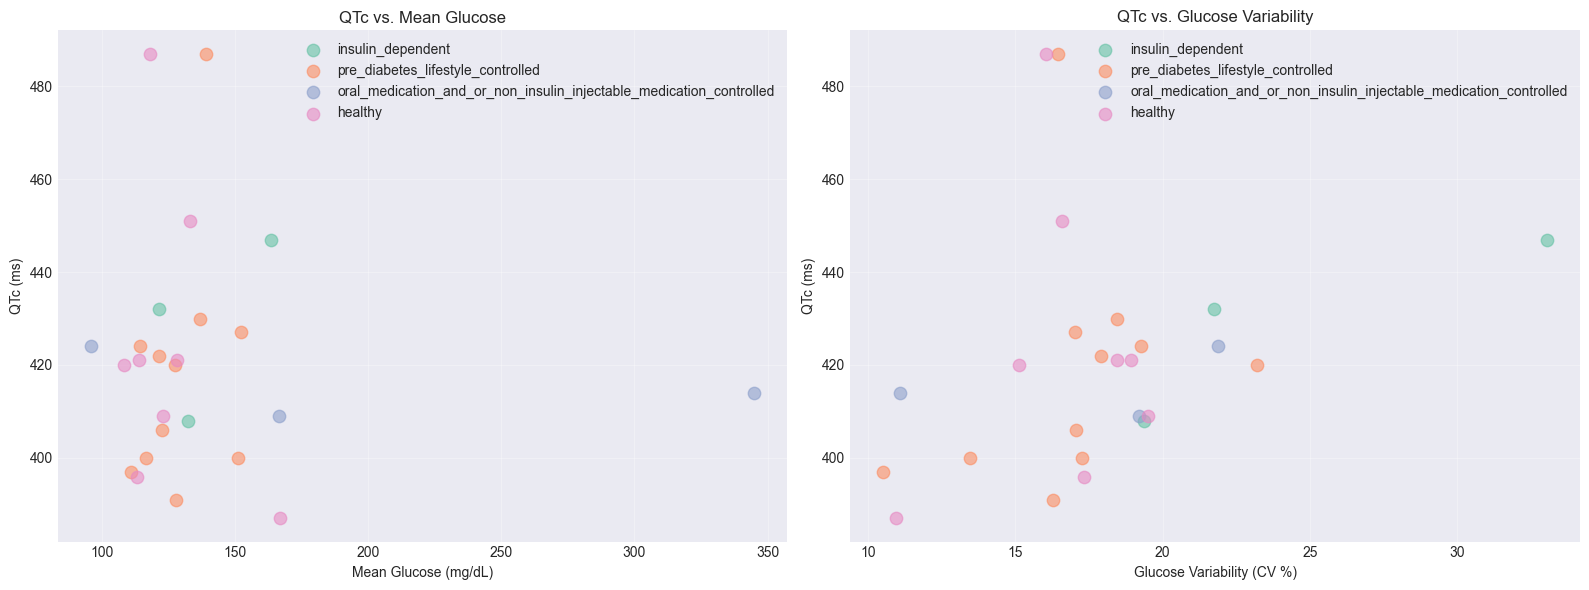


QTc correlation with mean glucose: -0.054
QTc correlation with glucose variability: 0.286


In [17]:
# ECG metrics vs. glucose variability
if 'QTc' in df.columns and 'cv_glucose' in df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # QTc vs. mean glucose
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]
        ax1.scatter(group_data['mean_glucose'], group_data['QTc'], 
                   alpha=0.6, label=group, s=80)
    ax1.set_xlabel('Mean Glucose (mg/dL)')
    ax1.set_ylabel('QTc (ms)')
    ax1.set_title('QTc vs. Mean Glucose')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # QTc vs. glucose variability
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]
        ax2.scatter(group_data['cv_glucose'], group_data['QTc'], 
                   alpha=0.6, label=group, s=80)
    ax2.set_xlabel('Glucose Variability (CV %)')
    ax2.set_ylabel('QTc (ms)')
    ax2.set_title('QTc vs. Glucose Variability')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation analysis
    corr_mean = df[['mean_glucose', 'QTc']].corr().iloc[0, 1]
    corr_cv = df[['cv_glucose', 'QTc']].corr().iloc[0, 1]
    print(f"\nQTc correlation with mean glucose: {corr_mean:.3f}")
    print(f"QTc correlation with glucose variability: {corr_cv:.3f}")

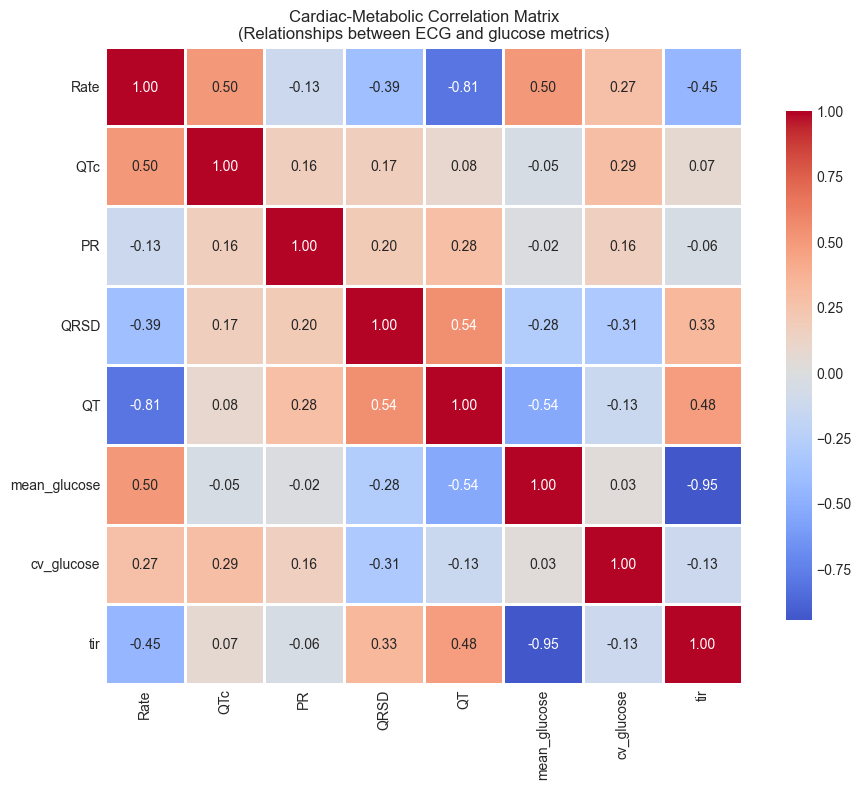

In [18]:
# Multi-metric cardiac-metabolic correlation
if len(available_ecg) > 0:
    ecg_glucose_cols = available_ecg + ['mean_glucose', 'cv_glucose', 'tir']
    ecg_glucose_cols = [col for col in ecg_glucose_cols if col in df.columns]
    
    plt.figure(figsize=(10, 8))
    corr_matrix = df[ecg_glucose_cols].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Cardiac-Metabolic Correlation Matrix\n(Relationships between ECG and glucose metrics)')
    plt.tight_layout()
    plt.show()

## 6. Lifestyle & Behavior Patterns

**How do physical activity, sleep, and stress affect glucose control?**

These are modifiable risk factors that can improve diabetes management.

In [19]:
# Check for activity data
activity_cols = ['average_daily_activity', 'average_sleep_hours', 'average_stress_level',
                'average_heartrate_bpm', 'average_oxygen_saturation_pct', 'average_active_calories_kcal']
available_activity = [col for col in activity_cols if col in df.columns]

if len(available_activity) > 0:
    print(f"✓ Activity data available: {available_activity}")
else:
    print("⚠️ No activity data in merged dataset")
    print("Skipping lifestyle analysis")

✓ Activity data available: ['average_daily_activity', 'average_sleep_hours', 'average_stress_level', 'average_heartrate_bpm', 'average_oxygen_saturation_pct', 'average_active_calories_kcal']


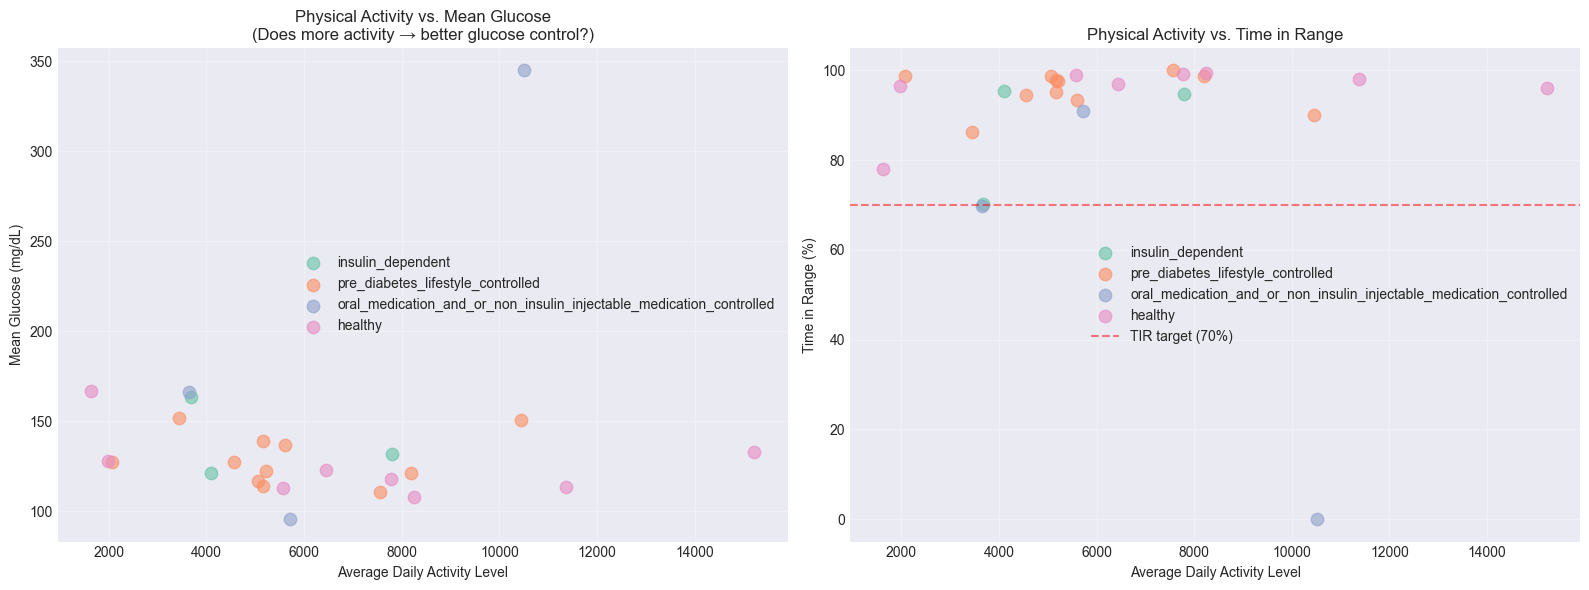


Activity correlation with mean glucose: 0.146
Activity correlation with TIR: -0.107


In [20]:
# Physical activity vs. glucose control
if 'average_daily_activity' in df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Activity vs. mean glucose
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]
        ax1.scatter(group_data['average_daily_activity'], group_data['mean_glucose'],
                   alpha=0.6, label=group, s=80)
    ax1.set_xlabel('Average Daily Activity Level')
    ax1.set_ylabel('Mean Glucose (mg/dL)')
    ax1.set_title('Physical Activity vs. Mean Glucose\n(Does more activity → better glucose control?)')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Activity vs. TIR
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]
        ax2.scatter(group_data['average_daily_activity'], group_data['tir'],
                   alpha=0.6, label=group, s=80)
    ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='TIR target (70%)')
    ax2.set_xlabel('Average Daily Activity Level')
    ax2.set_ylabel('Time in Range (%)')
    ax2.set_title('Physical Activity vs. Time in Range')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Correlations
    corr_glucose = df[['average_daily_activity', 'mean_glucose']].corr().iloc[0, 1]
    corr_tir = df[['average_daily_activity', 'tir']].corr().iloc[0, 1]
    print(f"\nActivity correlation with mean glucose: {corr_glucose:.3f}")
    print(f"Activity correlation with TIR: {corr_tir:.3f}")

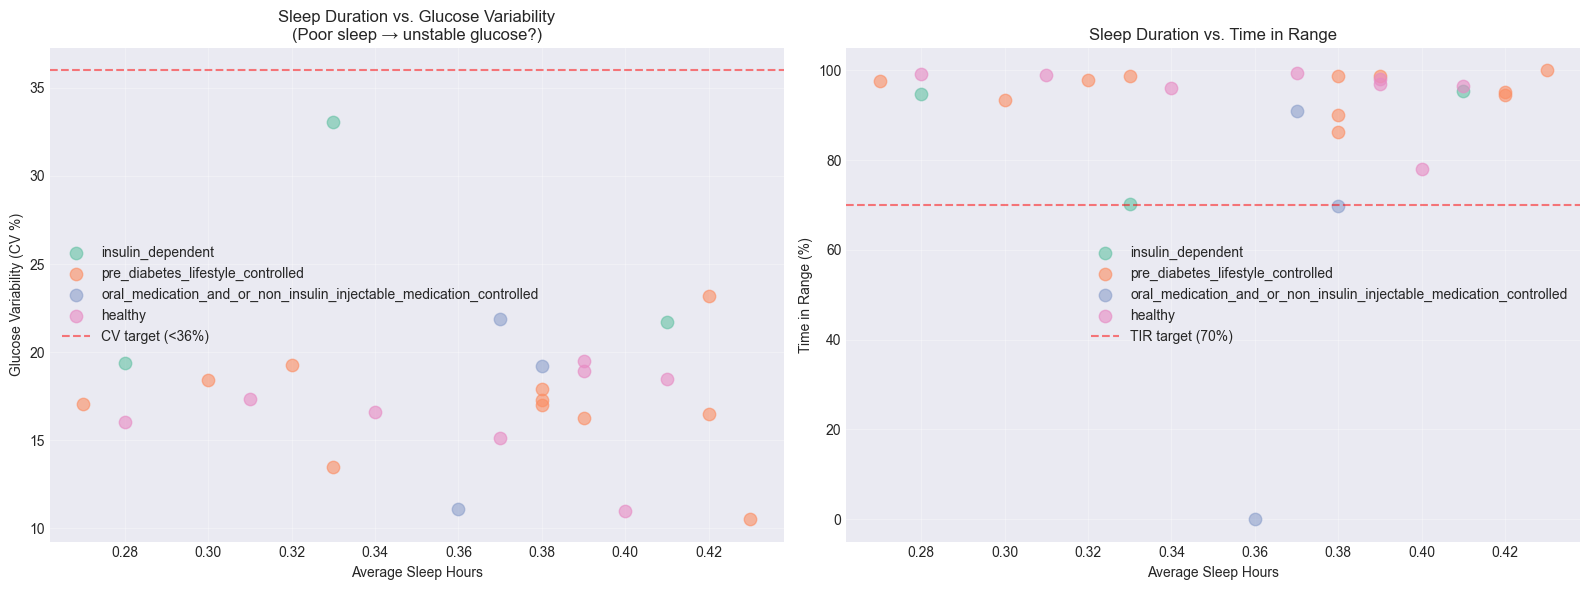


Sleep correlation with glucose variability: -0.107
Sleep correlation with TIR: -0.026


In [21]:
# Sleep duration vs. glycemic variability
if 'average_sleep_hours' in df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Sleep vs. CV
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]
        ax1.scatter(group_data['average_sleep_hours'], group_data['cv_glucose'],
                   alpha=0.6, label=group, s=80)
    ax1.axhline(36, color='red', linestyle='--', alpha=0.5, label='CV target (<36%)')
    ax1.set_xlabel('Average Sleep Hours')
    ax1.set_ylabel('Glucose Variability (CV %)')
    ax1.set_title('Sleep Duration vs. Glucose Variability\n(Poor sleep → unstable glucose?)')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Sleep vs. TIR
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]
        ax2.scatter(group_data['average_sleep_hours'], group_data['tir'],
                   alpha=0.6, label=group, s=80)
    ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='TIR target (70%)')
    ax2.set_xlabel('Average Sleep Hours')
    ax2.set_ylabel('Time in Range (%)')
    ax2.set_title('Sleep Duration vs. Time in Range')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    corr_cv = df[['average_sleep_hours', 'cv_glucose']].corr().iloc[0, 1]
    corr_tir = df[['average_sleep_hours', 'tir']].corr().iloc[0, 1]
    print(f"\nSleep correlation with glucose variability: {corr_cv:.3f}")
    print(f"Sleep correlation with TIR: {corr_tir:.3f}")

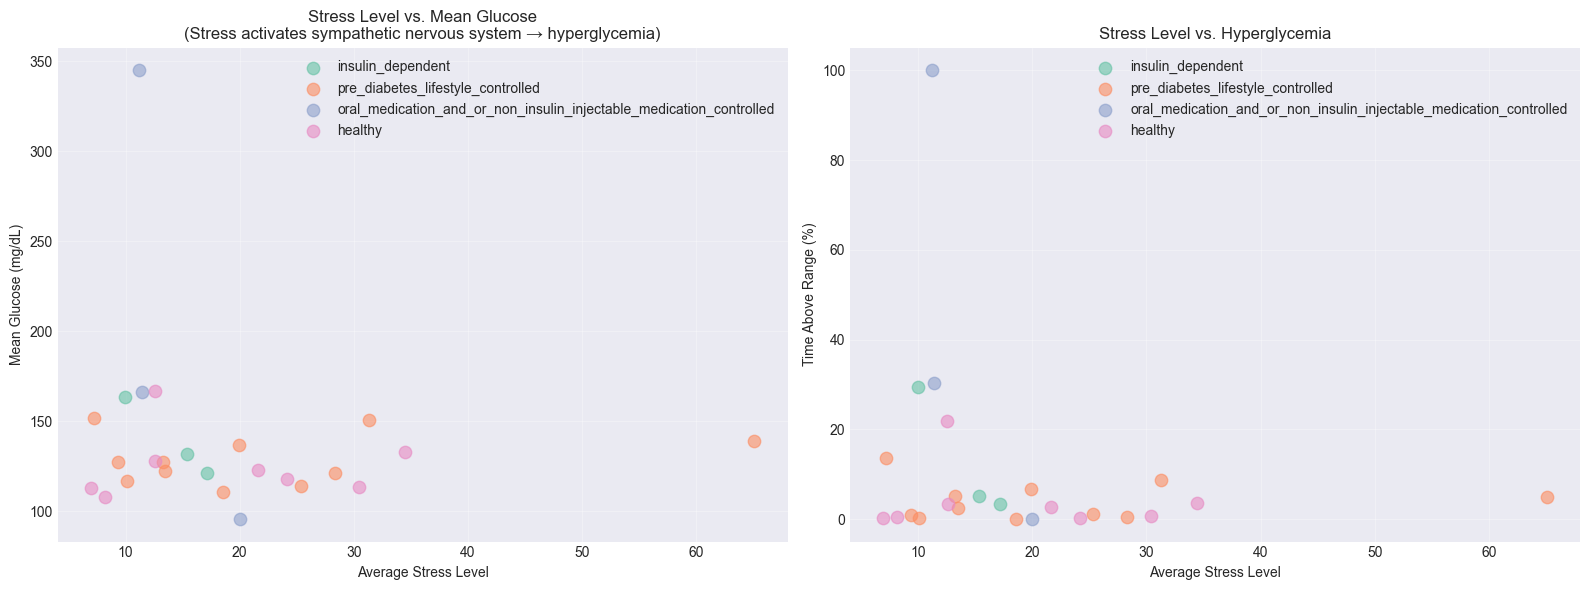


Stress correlation with mean glucose: -0.133
Stress correlation with hyperglycemia (TAR): -0.209


In [22]:
# Stress level vs. glucose metrics
if 'average_stress_level' in df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Stress vs. mean glucose
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]
        ax1.scatter(group_data['average_stress_level'], group_data['mean_glucose'],
                   alpha=0.6, label=group, s=80)
    ax1.set_xlabel('Average Stress Level')
    ax1.set_ylabel('Mean Glucose (mg/dL)')
    ax1.set_title('Stress Level vs. Mean Glucose\n(Stress activates sympathetic nervous system → hyperglycemia)')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Stress vs. TAR (hyperglycemia)
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]
        ax2.scatter(group_data['average_stress_level'], group_data['tar'],
                   alpha=0.6, label=group, s=80)
    ax2.set_xlabel('Average Stress Level')
    ax2.set_ylabel('Time Above Range (%)')
    ax2.set_title('Stress Level vs. Hyperglycemia')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    corr_glucose = df[['average_stress_level', 'mean_glucose']].corr().iloc[0, 1]
    corr_tar = df[['average_stress_level', 'tar']].corr().iloc[0, 1]
    print(f"\nStress correlation with mean glucose: {corr_glucose:.3f}")
    print(f"Stress correlation with hyperglycemia (TAR): {corr_tar:.3f}")

Creating pairplot (this may take a moment)...


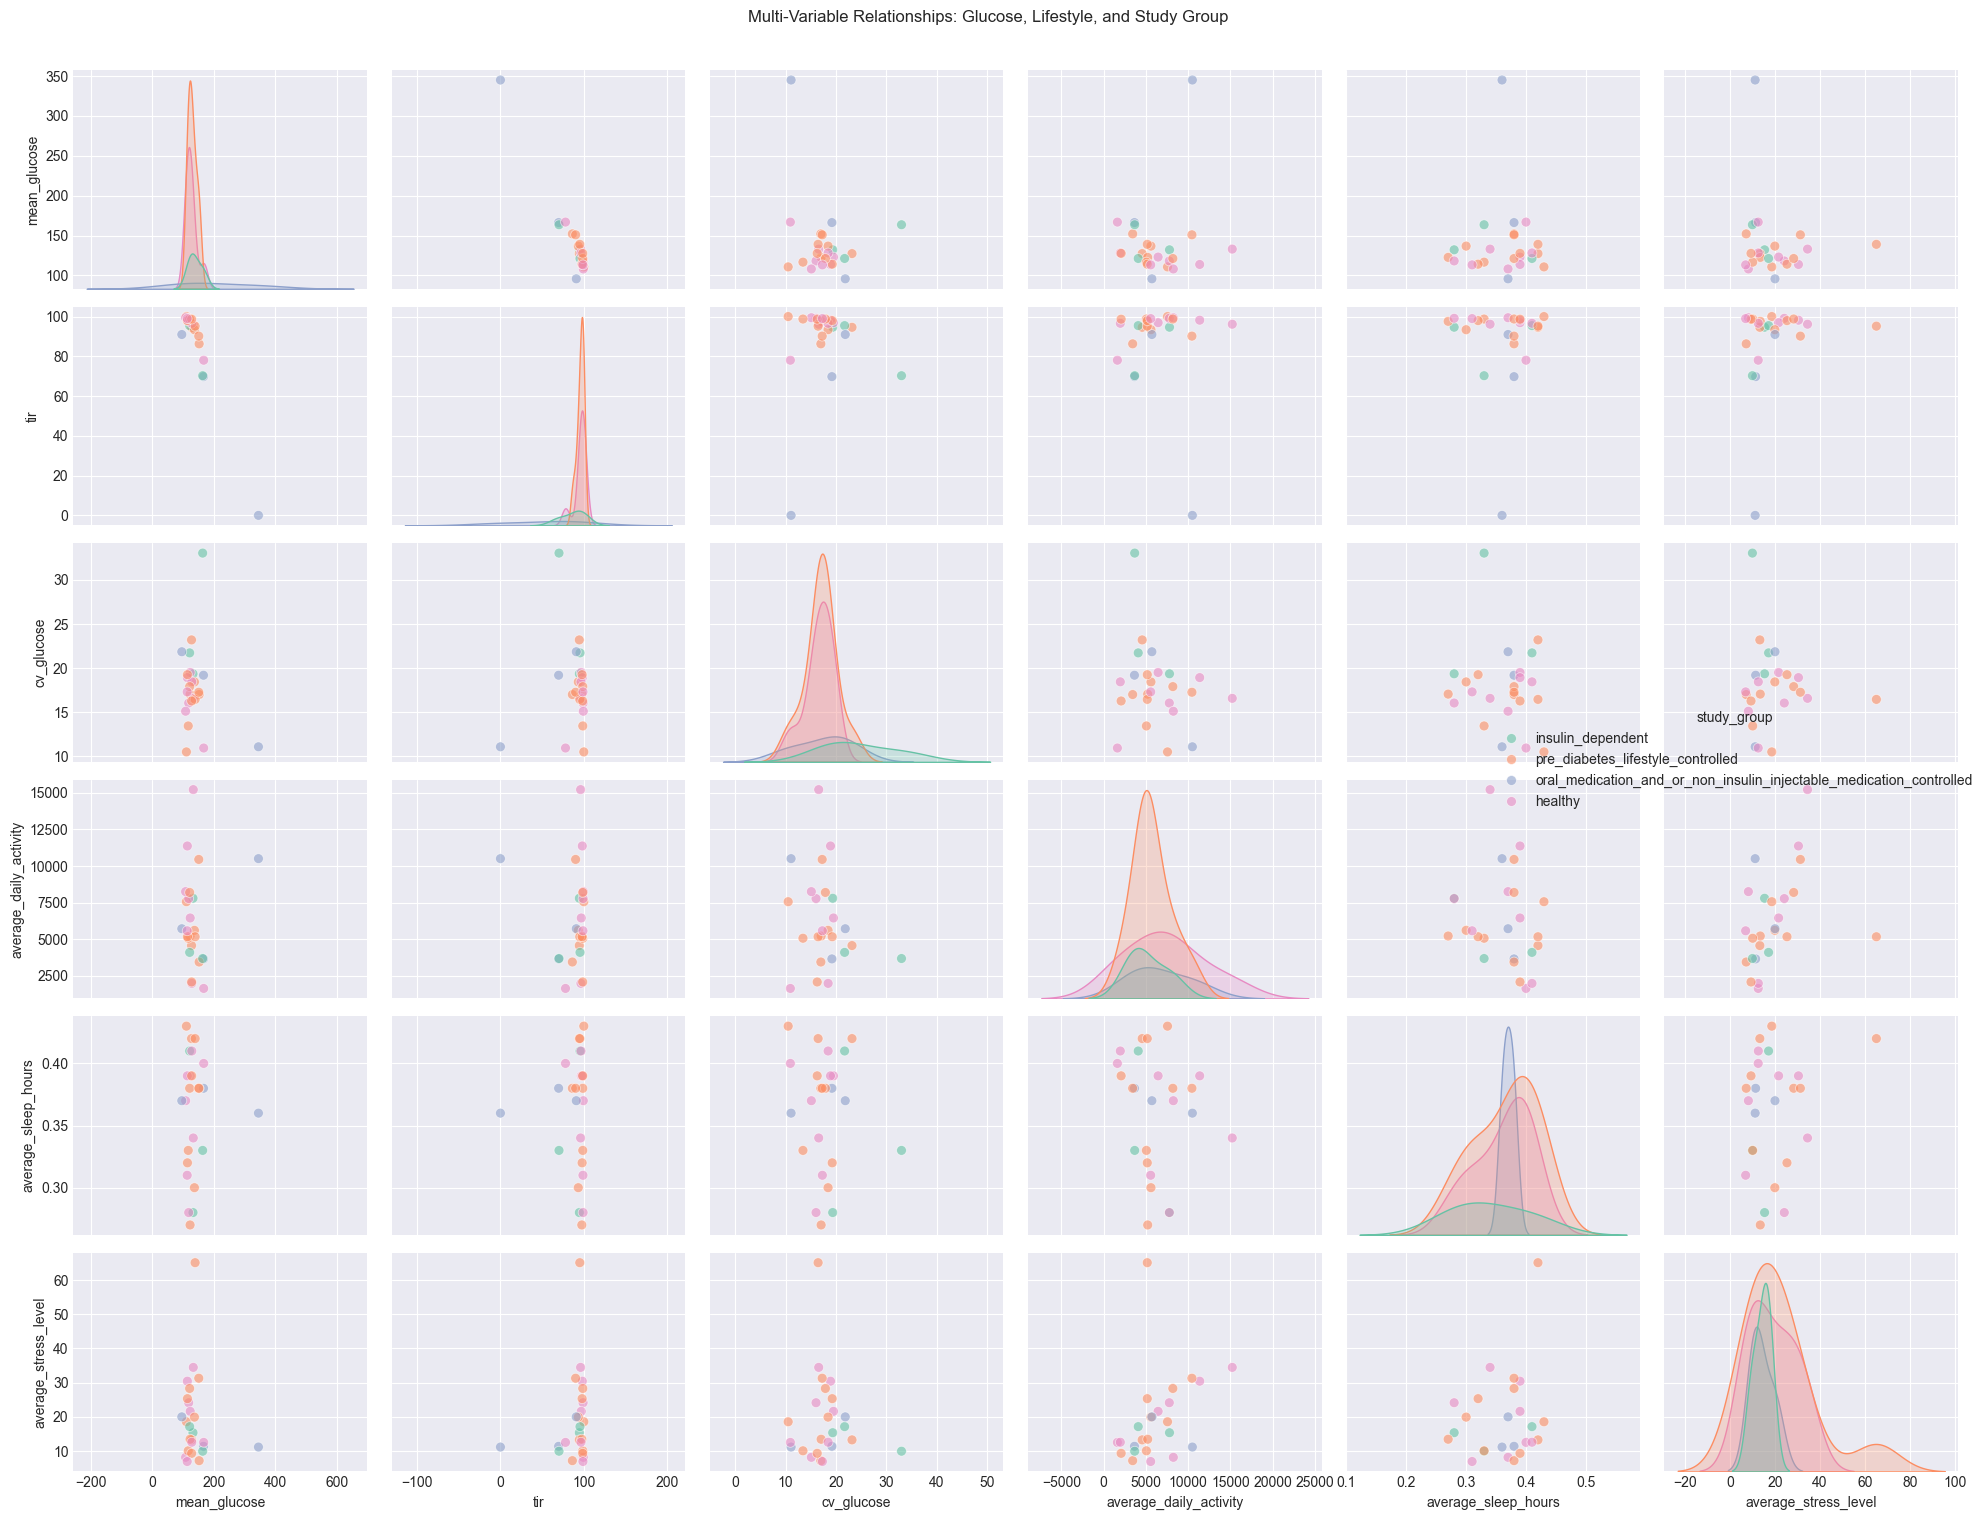

In [23]:
# Multi-variable pairplot (if we have activity data)
if len(available_activity) >= 2:
    # Select key columns for pairplot
    pairplot_cols = ['mean_glucose', 'tir', 'cv_glucose']
    
    # Add available activity metrics
    if 'average_daily_activity' in df.columns:
        pairplot_cols.append('average_daily_activity')
    if 'average_sleep_hours' in df.columns:
        pairplot_cols.append('average_sleep_hours')
    if 'average_stress_level' in df.columns:
        pairplot_cols.append('average_stress_level')
    
    pairplot_cols.append('study_group')
    
    print("Creating pairplot (this may take a moment)...")
    sns.pairplot(df[pairplot_cols].dropna(), hue='study_group', 
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 50})
    plt.suptitle('Multi-Variable Relationships: Glucose, Lifestyle, and Study Group', y=1.01)
    plt.tight_layout()
    plt.show()

## 7. Patient Phenotyping

**Can we identify distinct diabetes subtypes using multi-modal clustering?**

This section explores unsupervised learning to discover patient groups that share similar characteristics across glucose, cardiac, and lifestyle metrics.

In [28]:
# Prepare features for clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select features (glucose + cardiac + activity)
cluster_features = ['mean_glucose', 'cv_glucose', 'tir', 'tar', 'tbr']

# Add ECG if available
if 'Rate' in df.columns:
    cluster_features.append('Rate')
if 'QTc' in df.columns:
    cluster_features.append('QTc')

# Add activity if available
if 'average_daily_activity' in df.columns:
    cluster_features.append('average_daily_activity')
if 'average_sleep_hours' in df.columns:
    cluster_features.append('average_sleep_hours')
if 'average_stress_level' in df.columns:
    cluster_features.append('average_stress_level')

# Remove any features not in dataset
cluster_features = [f for f in cluster_features if f in df.columns]

print(f"Clustering features: {cluster_features}")

# Prepare data (drop missing values)
X = df[cluster_features].dropna()
print(f"\nParticipants with complete data: {len(X)}")

Clustering features: ['mean_glucose', 'cv_glucose', 'tir', 'tar', 'tbr', 'Rate', 'QTc', 'average_daily_activity', 'average_sleep_hours', 'average_stress_level']

Participants with complete data: 25


In [29]:
# Standardize features (important for clustering!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features standardized (mean=0, std=1)")
print("\nScaled data shape:", X_scaled.shape)

Features standardized (mean=0, std=1)

Scaled data shape: (25, 10)


In [30]:
# K-Means clustering
n_clusters = 4  # Try 4 clusters

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_clustered = df.loc[X.index].copy()
df_clustered['cluster'] = cluster_labels

print(f"✓ K-Means clustering complete with {n_clusters} clusters")
print("\nCluster distribution:")
print(df_clustered['cluster'].value_counts().sort_index())

✓ K-Means clustering complete with 4 clusters

Cluster distribution:
cluster
0    12
1     1
2    11
3     1
Name: count, dtype: int64


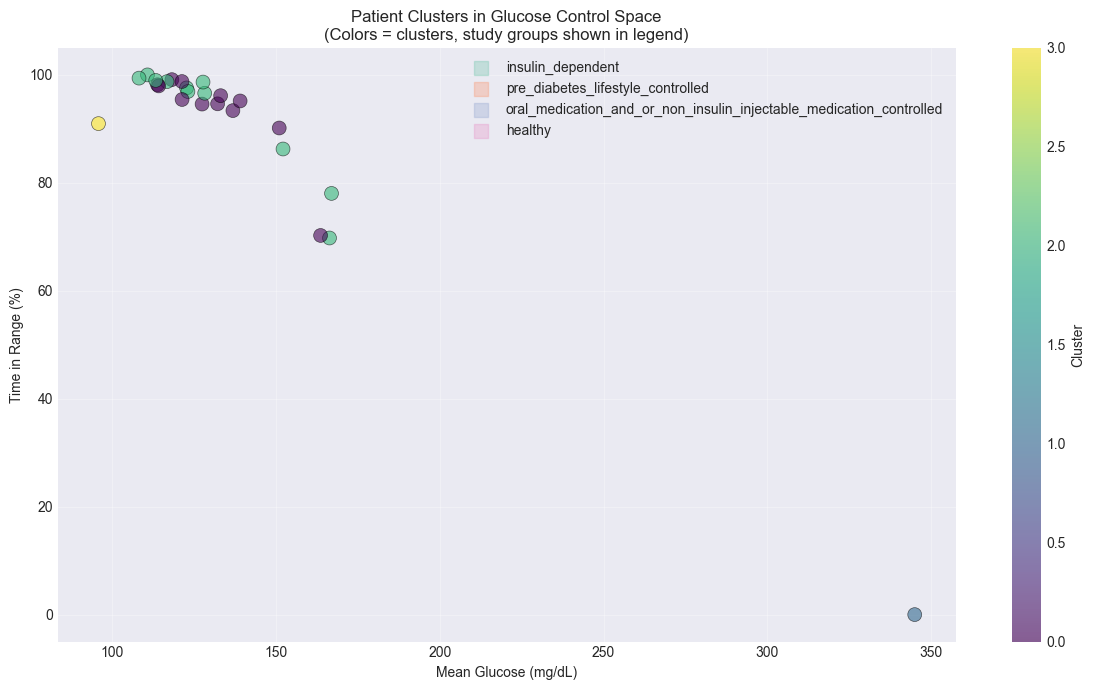

In [31]:
# Visualize clusters in glucose space (TIR vs. mean glucose)
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df_clustered['mean_glucose'], df_clustered['tir'], 
                     c=df_clustered['cluster'], cmap='viridis', 
                     s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

# Add study group markers
for i, group in enumerate(df_clustered['study_group'].unique()):
    group_data = df_clustered[df_clustered['study_group'] == group]
    plt.scatter([], [], marker='s', s=100, label=group, alpha=0.3)

plt.xlabel('Mean Glucose (mg/dL)')
plt.ylabel('Time in Range (%)')
plt.title('Patient Clusters in Glucose Control Space\n(Colors = clusters, study groups shown in legend)')
plt.colorbar(scatter, label='Cluster')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

PCA explained variance:
  PC1: 33.8%
  PC2: 22.1%
  Total: 55.9%


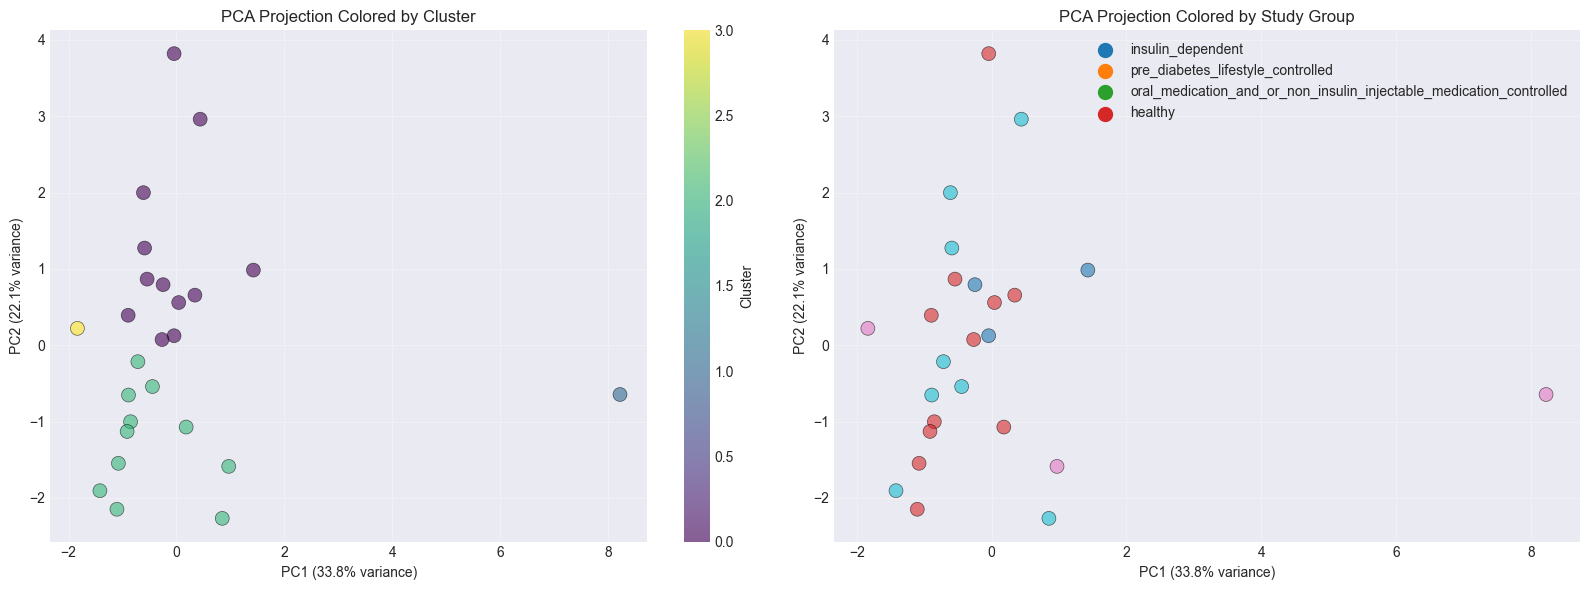

In [32]:
# PCA dimensionality reduction for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA explained variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Plot PCA with clusters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Colored by cluster
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, 
                      cmap='viridis', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax1.set_title('PCA Projection Colored by Cluster')
ax1.grid(alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Colored by study group
study_group_map = {group: i for i, group in enumerate(df_clustered['study_group'].unique())}
study_group_colors = df_clustered['study_group'].map(study_group_map)
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=study_group_colors,
                      cmap='tab10', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax2.set_title('PCA Projection Colored by Study Group')
ax2.grid(alpha=0.3)

# Add legend for study groups
for group, color_idx in study_group_map.items():
    ax2.scatter([], [], c=[plt.cm.tab10(color_idx)], label=group, s=100)
ax2.legend()

plt.tight_layout()
plt.show()

In [33]:
# Characterize each cluster
print("CLUSTER CHARACTERIZATION")
print("=" * 80)

for cluster_id in range(n_clusters):
    cluster_data = df_clustered[df_clustered['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} (n={len(cluster_data)}):")
    print("-" * 40)
    
    # Study group distribution
    print("Study group composition:")
    for group, count in cluster_data['study_group'].value_counts().items():
        pct = count / len(cluster_data) * 100
        print(f"  {group}: {count} ({pct:.1f}%)")
    
    # Key metrics
    print("\nGlucose profile:")
    print(f"  Mean glucose: {cluster_data['mean_glucose'].mean():.1f} mg/dL")
    print(f"  TIR: {cluster_data['tir'].mean():.1f}%")
    print(f"  TAR: {cluster_data['tar'].mean():.1f}%")
    print(f"  TBR: {cluster_data['tbr'].mean():.1f}%")
    print(f"  CV: {cluster_data['cv_glucose'].mean():.1f}%")
    
    if 'QTc' in cluster_data.columns:
        print("\nCardiac metrics:")
        print(f"  QTc: {cluster_data['QTc'].mean():.1f} ms")
        print(f"  Heart rate: {cluster_data['Rate'].mean():.1f} bpm")
    
    if 'average_daily_activity' in cluster_data.columns:
        print("\nLifestyle metrics:")
        print(f"  Activity: {cluster_data['average_daily_activity'].mean():.1f}")
        if 'average_sleep_hours' in cluster_data.columns:
            print(f"  Sleep: {cluster_data['average_sleep_hours'].mean():.1f} hours")
        if 'average_stress_level' in cluster_data.columns:
            print(f"  Stress: {cluster_data['average_stress_level'].mean():.1f}")

CLUSTER CHARACTERIZATION

Cluster 0 (n=12):
----------------------------------------
Study group composition:
  pre_diabetes_lifestyle_controlled: 6 (50.0%)
  insulin_dependent: 3 (25.0%)
  healthy: 3 (25.0%)

Glucose profile:
  Mean glucose: 131.0 mg/dL
  TIR: 93.7%
  TAR: 5.8%
  TBR: 0.5%
  CV: 19.9%

Cardiac metrics:
  QTc: 435.8 ms
  Heart rate: 77.2 bpm

Lifestyle metrics:
  Activity: 7424.3
  Sleep: 0.4 hours
  Stress: 26.2

Cluster 1 (n=1):
----------------------------------------
Study group composition:
  oral_medication_and_or_non_insulin_injectable_medication_controlled: 1 (100.0%)

Glucose profile:
  Mean glucose: 345.0 mg/dL
  TIR: 0.0%
  TAR: 100.0%
  TBR: 0.0%
  CV: 11.1%

Cardiac metrics:
  QTc: 414.0 ms
  Heart rate: 97.0 bpm

Lifestyle metrics:
  Activity: 10505.2
  Sleep: 0.4 hours
  Stress: 11.2

Cluster 2 (n=11):
----------------------------------------
Study group composition:
  pre_diabetes_lifestyle_controlled: 5 (45.5%)
  healthy: 5 (45.5%)
  oral_medication_an

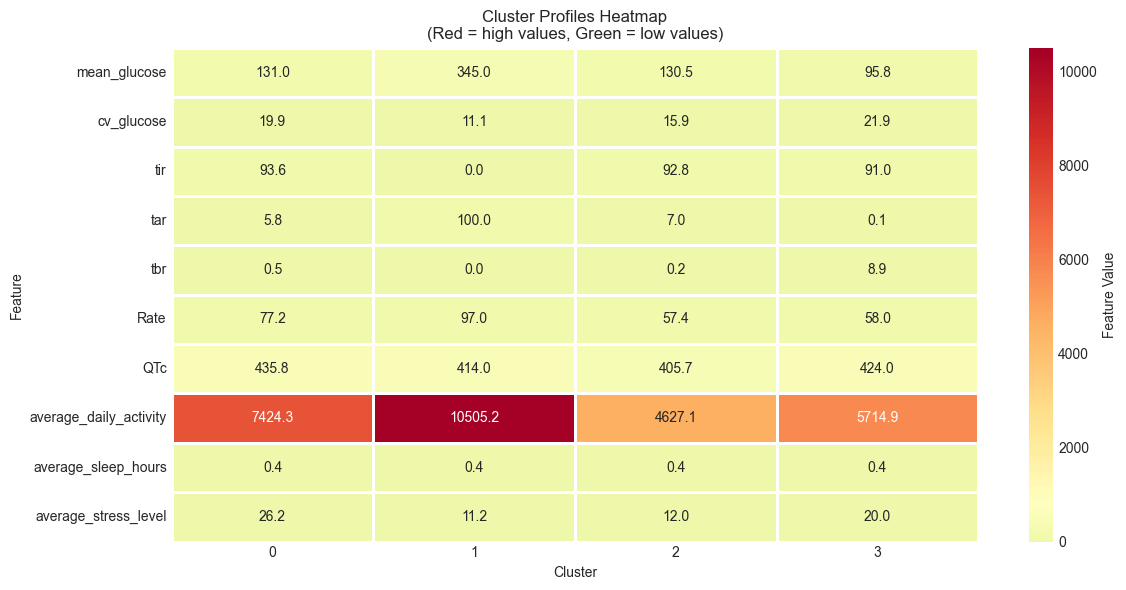

In [34]:
# Heatmap of cluster profiles
cluster_summary = df_clustered.groupby('cluster')[cluster_features].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary.T, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            center=cluster_summary.values.mean(), linewidths=1,
            cbar_kws={'label': 'Feature Value'})
plt.title('Cluster Profiles Heatmap\n(Red = high values, Green = low values)')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Clinical Patterns

**Brief exploration of clinical data patterns from OMOP CDM tables.**

In [35]:
# Check for clinical site information
if 'clinical_site' in df.columns:
    print("Clinical Site Distribution:")
    print(df['clinical_site'].value_counts())
    
    # Site vs. study group cross-tab
    print("\nStudy group by clinical site:")
    print(pd.crosstab(df['clinical_site'], df['study_group']))
else:
    print("Clinical site information not available")

Clinical Site Distribution:
clinical_site
UW      36
UCSD     8
UAB      8
Name: count, dtype: int64

Study group by clinical site:
study_group    healthy  insulin_dependent  \
clinical_site                               
UAB                  1                  4   
UCSD                 3                  0   
UW                  11                  6   

study_group    oral_medication_and_or_non_insulin_injectable_medication_controlled  \
clinical_site                                                                        
UAB                                                            2                     
UCSD                                                           2                     
UW                                                             6                     

study_group    pre_diabetes_lifestyle_controlled  
clinical_site                                     
UAB                                            1  
UCSD                                           3  
UW     

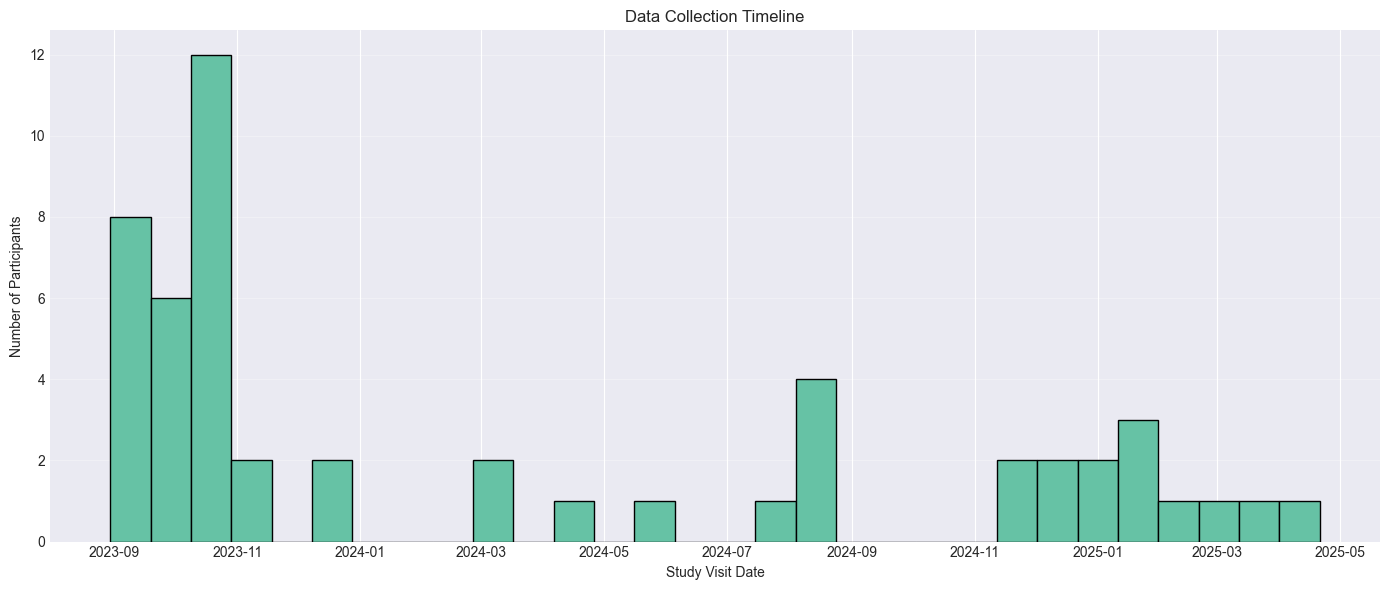

Data collection period: 2023-08-30 00:00:00 to 2025-04-21 00:00:00


In [36]:
# Temporal analysis (if study visit dates available)
if 'study_visit_date' in df.columns:
    df['visit_date'] = pd.to_datetime(df['study_visit_date'])
    
    plt.figure(figsize=(14, 6))
    df['visit_date'].hist(bins=30, edgecolor='black')
    plt.xlabel('Study Visit Date')
    plt.ylabel('Number of Participants')
    plt.title('Data Collection Timeline')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Data collection period: {df['visit_date'].min()} to {df['visit_date'].max()}")
else:
    print("Study visit date information not available")

## 9. Key Findings & Summary

**Summary of main insights from the exploratory data analysis.**

In [37]:
# Generate comprehensive summary table
print("COMPREHENSIVE SUMMARY BY STUDY GROUP")
print("=" * 80)

summary_cols = ['mean_glucose', 'tir', 'tar', 'tbr', 'cv_glucose']
if 'Rate' in df.columns:
    summary_cols.append('Rate')
if 'QTc' in df.columns:
    summary_cols.append('QTc')

summary_stats = df.groupby('study_group')[summary_cols].agg(['mean', 'std'])
print(summary_stats.round(1))

print("\n" + "=" * 80)
print("KEY FINDINGS:")
print("=" * 80)

# Find key insights
print("\n1. GLUCOSE CONTROL:")
for group in df['study_group'].unique():
    group_data = df[df['study_group'] == group]
    tir_mean = group_data['tir'].mean()
    meeting_target = (group_data['tir'] > 70).mean() * 100
    print(f"   {group}:")
    print(f"     - Mean TIR: {tir_mean:.1f}%")
    print(f"     - Meeting target (>70%): {meeting_target:.1f}% of participants")

if 'QTc' in df.columns:
    print("\n2. CARDIAC HEALTH:")
    prolonged_overall = (df['QTc'] > 450).mean() * 100
    print(f"   Overall prolonged QTc (>450ms): {prolonged_overall:.1f}% of participants")
    
    for group in df['study_group'].unique():
        group_data = df[df['study_group'] == group]
        prolonged = (group_data['QTc'] > 450).mean() * 100
        print(f"   {group}: {prolonged:.1f}%")

if len(available_activity) > 0:
    print("\n3. LIFESTYLE FACTORS:")
    if 'average_daily_activity' in df.columns:
        corr_activity = df[['average_daily_activity', 'tir']].corr().iloc[0, 1]
        print(f"   Activity-TIR correlation: {corr_activity:.3f}")
    if 'average_sleep_hours' in df.columns:
        corr_sleep = df[['average_sleep_hours', 'cv_glucose']].corr().iloc[0, 1]
        print(f"   Sleep-glucose variability correlation: {corr_sleep:.3f}")

print("\n" + "=" * 80)

COMPREHENSIVE SUMMARY BY STUDY GROUP
                                                   mean_glucose         tir  \
                                                           mean   std  mean   
study_group                                                                   
healthy                                                   124.9  21.0  94.1   
insulin_dependent                                         173.0  50.7  61.0   
oral_medication_and_or_non_insulin_injectable_m...        159.4  68.5  78.2   
pre_diabetes_lifestyle_controlled                         126.9  14.6  95.3   

                                                           tar        tbr  \
                                                     std  mean   std mean   
study_group                                                                 
healthy                                             11.7   5.7  11.8  0.3   
insulin_dependent                                   34.2  38.7  34.5  0.3   
oral_medication_and_or_n

## 10. Next Steps & ML Roadmap

**Based on this exploratory analysis, here are recommended next steps for machine learning development.**

In [38]:
print("MACHINE LEARNING ROADMAP")
print("=" * 80)

print("""
PHASE 1: FEATURE ENGINEERING ✓ (Current Phase Complete)
- Downloaded and merged multi-modal data
- Calculated glucose metrics (TIR, TAR, TBR, CV, GMI)
- Explored correlations and patterns
- Identified patient phenotypes via clustering

PHASE 2: PREDICTIVE MODELING (Next Steps)

Goal: Predict glucose levels and identify diabetic spike patterns

Approach 1: Time Series Forecasting
  - Use CGM time series data (5-minute intervals)
  - Features: Past glucose values, time of day, activity, sleep
  - Models: LSTM, GRU, or Transformer architectures
  - Target: Predict next-hour glucose or classify hypo/normal/hyper state

Approach 2: Spike Detection
  - Define "spike": Rapid glucose increase (e.g., >50 mg/dL in 30 min)
  - Features: Recent glucose trend, activity, meal timing (if available)
  - Models: Random Forest, XGBoost for classification
  - Target: Binary classification (spike / no spike in next hour)

Approach 3: Personalized Models
  - Train separate models for each participant
  - Extract model weights/coefficients
  - Cluster participants by weight similarity
  - Goal: Discover mechanistic diabetes subtypes

PHASE 3: MODEL WEIGHT CLUSTERING (Your Original Idea!)

After training personalized models:
  1. Extract feature importance or model coefficients for each participant
  2. Cluster participants by their weight vectors
  3. Characterize clusters:
     - "Glucose-activity sensitive" group
     - "Glucose-sleep sensitive" group
     - "Insulin-responsive" vs. "insulin-resistant" patterns
  4. Compare to clinical study groups and phenotype clusters

Expected Insights:
  - Clusters may reveal response mechanisms not captured by clinical labels
  - Inform personalized treatment strategies
  - Identify which modalities matter most for each patient type

PHASE 4: CLINICAL VALIDATION
  - Validate predictions against held-out data
  - Compare model clusters to clinical outcomes
  - Assess clinical utility and interpretability

""")

print("=" * 80)
print("RECOMMENDED FEATURES FOR ML MODELS:")
print("=" * 80)

print("""
HIGH PRIORITY FEATURES (strong correlations observed):
  - Past glucose values (autoregressive features)
  - Time of day (circadian patterns)
  - Glucose variability metrics (CV, std)
  - Study group (disease severity proxy)

MEDIUM PRIORITY FEATURES (moderate correlations):
  - Physical activity level
  - Sleep duration
  - Heart rate
  - Stress level

EXPLORATORY FEATURES (weak correlations, but may be important):
  - QTc interval
  - PR interval, QRS duration
  - Environmental factors (temperature, humidity)

TEMPORAL FEATURES TO ENGINEER:
  - Rolling glucose mean/std (15min, 1hr, 3hr windows)
  - Glucose rate of change (derivative)
  - Time since last meal (if available)
  - Recent activity/sleep quality

""")

print("=" * 80)
print("NEXT STEPS:")
print("=" * 80)
print("""
1. Download full CGM time series for selected participants
2. Create temporal feature engineering pipeline
3. Implement baseline LSTM glucose prediction model
4. Evaluate prediction accuracy and spike detection performance
5. Train personalized models and extract weights
6. Cluster by model weights and characterize groups
7. Validate against clinical outcomes

Ready to begin Phase 2!
""")

print("=" * 80)

MACHINE LEARNING ROADMAP

PHASE 1: FEATURE ENGINEERING ✓ (Current Phase Complete)
- Downloaded and merged multi-modal data
- Calculated glucose metrics (TIR, TAR, TBR, CV, GMI)
- Explored correlations and patterns
- Identified patient phenotypes via clustering

PHASE 2: PREDICTIVE MODELING (Next Steps)

Goal: Predict glucose levels and identify diabetic spike patterns

Approach 1: Time Series Forecasting
  - Use CGM time series data (5-minute intervals)
  - Features: Past glucose values, time of day, activity, sleep
  - Models: LSTM, GRU, or Transformer architectures
  - Target: Predict next-hour glucose or classify hypo/normal/hyper state

Approach 2: Spike Detection
  - Define "spike": Rapid glucose increase (e.g., >50 mg/dL in 30 min)
  - Features: Recent glucose trend, activity, meal timing (if available)
  - Models: Random Forest, XGBoost for classification
  - Target: Binary classification (spike / no spike in next hour)

Approach 3: Personalized Models
  - Train separate models 

---

## Conclusion

This exploratory data analysis has provided insights into:
- **Cohort characteristics**: Distribution across diabetes severity levels
- **Glucose dynamics**: Time in range, variability, and hyperglycemia patterns
- **Cardiac-metabolic relationships**: QTc prolongation and its association with glucose
- **Lifestyle factors**: Activity, sleep, and stress correlations with glucose control
- **Patient phenotypes**: Distinct clusters with different multi-modal signatures

**The AI-READI dataset is now ready for predictive modeling and personalized diabetes insights!**

For medical background and dataset details, see:
- [AIREADI_INTRO.md](../guides/AIREADI_INTRO.md) - Comprehensive diabetes and dataset reference
- [INITIAL_DATA_INSPECTION_GUIDE.md](../guides/INITIAL_DATA_INSPECTION_GUIDE.md) - Initial data inspection documentation

---